# Reto Spaceship Titanic - Tercer Avance

| | |
|---|---|
| **Equipo** | Israel González Huerta A01751433<br>Luis David Pozos Tamez A01800657<br>Adrián Proaño Bernal A01752615<br>Juan Pablo Solís Gómez A01800430<br>Karol Alexis Alvarado Davila A01751711 |
| **Fecha** | 17 de septiembre de 2026 |

---

## 1. Carga y comprensión del dataset

### 1.1 Carga de `train.csv` y `test.csv`

Carga de los conjuntos de entrenamiento y prueba provistos por Kaggle. No se realiza split adicional: todo el trabajo de preparación se desarrolla sobre `train.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import export_text

import math

In [2]:
train = pd.read_csv('../data/titanic_data/train.csv')
test = pd.read_csv('../data/titanic_data/test.csv')

### 1.2 Inspección de estructura: shape, tipos de variables y primeras filas

Revisión del número de filas y columnas, tipos de datos (`dtypes`) por variable, y muestra de las primeras observaciones (`head`) para comprender el formato general del dataset.

In [3]:
print(test.shape)
print(train.shape)

(4277, 13)
(8693, 14)


In [4]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [6]:
train.dtypes

PassengerId         str
HomePlanet          str
CryoSleep        object
Cabin               str
Destination         str
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name                str
Transported        bool
dtype: object

### 1.3 Identificación de la variable target y tipo de problema

`Transported` es nuestra variable objetivo. El problema que se está intentando resolver en este escenario es identificar a los pasajeros que fueron transportados a la dimensión alterna, por lo que cuadra perfectamente con el dato booleano que aparece en el training set. 

El tipo de problema al que nos enfrentamos es una **clasificación binaria supervisada**, ya que la predicción solo puede caer en dos categorías, y además tenemos acceso a una muestra con valores predefinidos de True/False para `Transported` (test.csv). A partir de esto podemos verificar algunas de las respuestas que da el modelo y proporcionarle retroalimentación.

## 2. Análisis exploratorio (EDA)

### 2.1 Valores faltantes: porcentaje por columna y clasificación (informativo vs. real)

Cálculo del porcentaje de faltantes por columna. Cada variable se clasifica como **faltante informativo** o **faltante real**, justificando cada clasificación con el contexto del dataset descrito en Kaggle.

In [7]:
faltantes = train.isnull().sum()
faltantes / len(train) * 100

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

**Check extra:** confirmar la hipótesis acerca del CryoSleep. Los pasajeros no deberían de gastar si están en este estado

In [8]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
total_spend = train[spend_cols].sum(axis=1, skipna=True)
check = train.loc[train["CryoSleep"].notna() & (total_spend > 0), "CryoSleep"]
print((check == True).sum(), "de", len(check))
print(check.value_counts(dropna=False))

0 de 4921
CryoSleep
False    4921
Name: count, dtype: int64


**Tabla de clasificación de variables**

| Variable | Faltante | Justificación |
|---|---|---|
| CryoSleep | Faltante real  | Un pasajero dormido no puede consumir. Si el gasto es > 0, CryoSleep debe ser false. Entonces los casos faltantes, son un hueco. |
| ShoppingMall |Faltante informativo  | Siguiendo con el razonamiento anterior, si CyroSleep es true, ShoppingMall debe ser 0. Entonces el pasajero no gastó nada. Si CryoSleep es False o desconocido, es un faltante real que requiere imputación estadística (mediana condicionada a pasajeros despiertos).  |
| VIP | Faltante real  | No hay motivo lógico por el que la ausencia signifique algo sistinto a "no se capturó". |
| HomePlanet | Faltante real | Su ausencia es porque no se capturó. Puede ser posible recuperarla por relaciones de miembros del mosmo grupo, deck o cabin |
| Name | Faltante real | No es relevante. Su ausencia no aporta nada al target, además es un identificador casi único. |
| Cabin | Faltante real | Si falta, no afecta al target, puede ser una falta de captura y no necesariamente que el pasajero no tenga cabina. |
| VRDeck | Faltante informativo | Igual que ShoppingMall, si CryoSleep es true, tiene que ser 0. Se tendría que comprobar que el pasajero está o estuvo activo para imputar el faltante. |
| Spa | Faltante informativo | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| FoodCourt | Faltante informativo  | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| Destination | Faltante real | La ausencia es porque no se capturó. Nota (ver 3.1): esta fila se anotó originalmente como "el destino no aporta nada al target"; el crosstab de la sección 3.1 corrigió esa conclusión al mostrar una diferencia consistente con Transported. |
| RoomService | Faltante informativo | Igual que las otras amenidades. Debe ser 0 con CryoSleep true, y es faltante de captura en pasajeros activos. |
| Age | Faltante real | Al igual que el nombre, no hay razón por la que "sin edad" signifique algo. No tiene relación determinística con otras variables. |

### 2.2 Variables numéricas: distribución, skewness y outliers

Histogramas de las variables numéricas, cálculo de asimetría (skewness) y detección de outliers mediante el método de Tukey/rango intercuartílico (IQR).

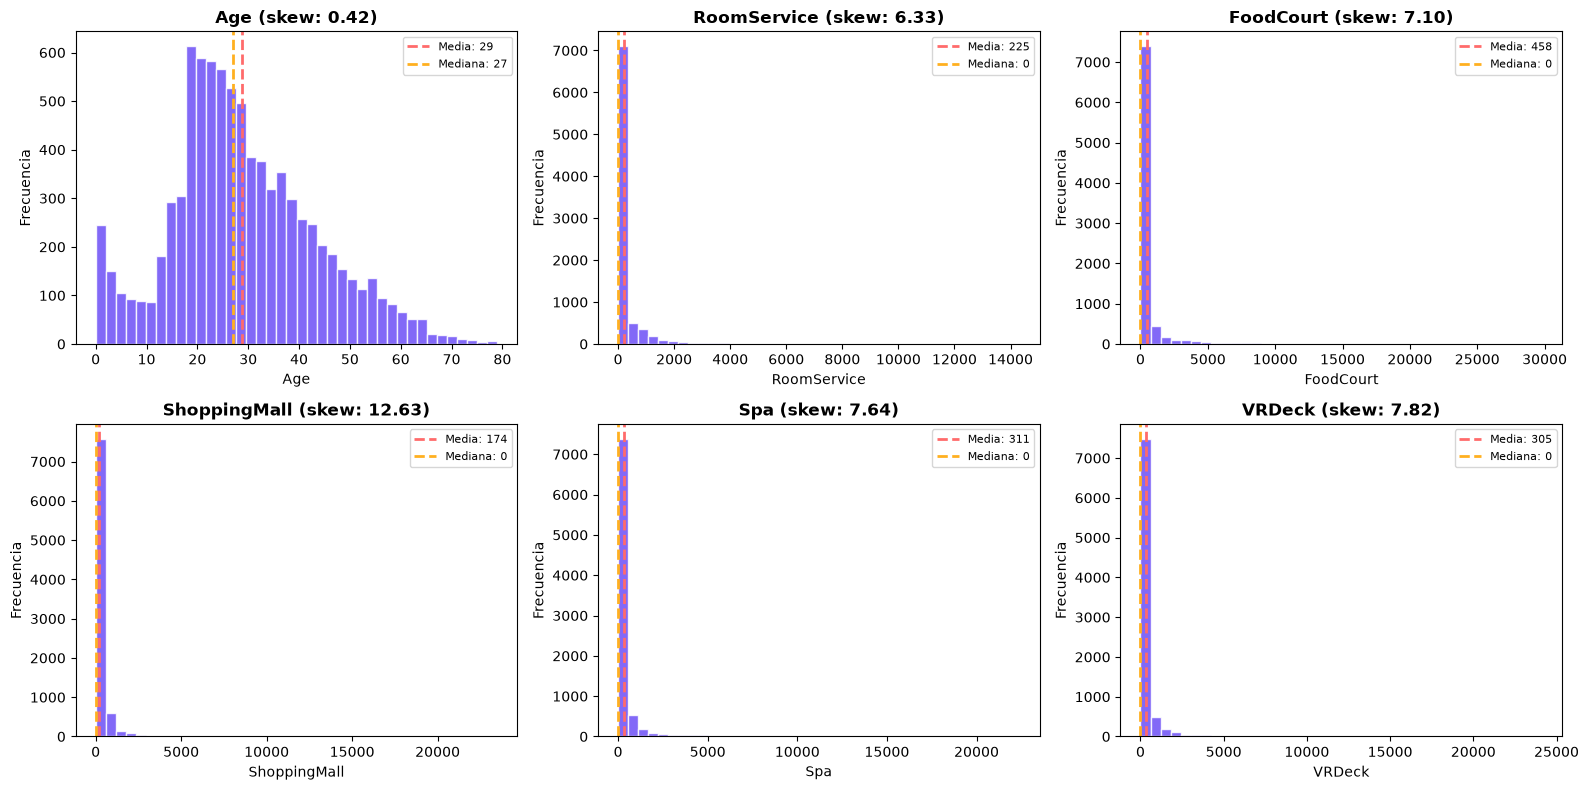

In [9]:
cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, col in zip(axes.flat, cols):
    ax.hist(train[col].dropna(), bins=40, color='#6C4FF6', edgecolor='white', alpha=0.85)
    ax.axvline(train[col].mean(), color='#FF6B6B', linewidth=2,
               linestyle='--', label=f"Media: {train[col].mean():,.0f}")
    ax.axvline(train[col].median(), color='#FFB020', linewidth=2,
               linestyle='--', label=f"Mediana: {train[col].median():,.0f}")

    ax.set_title(f"{col} (skew: {train[col].skew():.2f})", fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [10]:
info_outliers = []

for col in cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = train[(train[col] < lim_inf) | (train[col] > lim_sup)]

    info_outliers.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite inferior': lim_inf,
        'Límite superior': lim_sup,
        'Num outliers': len(outliers),
        'Porcentaje outliers': len(outliers) / len(train) * 100
    })

outliers_df = pd.DataFrame(info_outliers)

outliers_df

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Num outliers,Porcentaje outliers
0,Age,19.0,38.0,19.0,-9.5,66.5,77,0.885770
1,RoomService,0.0,47.0,47.0,-70.5,117.5,1861,21.408029
2,FoodCourt,0.0,76.0,76.0,-114.0,190.0,1823,20.970896
3,ShoppingMall,0.0,27.0,27.0,-40.5,67.5,1829,21.039917
4,Spa,0.0,59.0,59.0,-88.5,147.5,1788,20.568273
5,VRDeck,0.0,46.0,46.0,-69.0,115.0,1809,20.809847


### 2.3 Variables categóricas: cardinalidad, distribución y desbalance

Análisis de la cardinalidad de cada variable categórica, distribución de sus categorías y detección de variables con desbalance extremo entre clases.

In [11]:
v_categoricas = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin']

""" for col in v_categoricas:
    print(f"Valores en {col}:")
    print(train[col].value_counts())
 """

cardinalidad = train[v_categoricas].nunique().sort_values(ascending=False)
cardinalidad

Cabin          6560
HomePlanet        3
Destination       3
CryoSleep         2
VIP               2
dtype: int64

Cabin tiene una cardinalidad demasiado alta, pero es una variable compuesta. Podemos separar Deck, Side y NumCabin para analizar si alguna de estas variables tiene una cardinalidad más baja y que pueda ser de verdadera utilidad para el modelo.

In [12]:
train[['Deck', 'NumCabin', 'Side']] = train['Cabin'].str.split('/', expand=True)
train['NumCabin'] = pd.to_numeric(train['NumCabin'])

test[['Deck', 'NumCabin', 'Side']] = test['Cabin'].str.split('/', expand=True)
test['NumCabin'] = pd.to_numeric(test['NumCabin'])

Comprobamos la cardinalidad otra vez con las nuevas columnas:

In [13]:
v_categoricas = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'NumCabin', 'Deck', 'Side']

cardinalidad = train[v_categoricas].nunique().sort_values(ascending=False)
cardinalidad

NumCabin       1817
Deck              8
HomePlanet        3
Destination       3
CryoSleep         2
VIP               2
Side              2
dtype: int64

### 2.4 Relación de cada variable con el target

Crosstabs entre variables categóricas y `Transported`, y boxplots de variables numéricas segmentados por `Transported`. Este análisis es la base para justificar qué variables entran y cuáles se descartan en la siguiente etapa. Se excluye NumCabin por cardinalidad

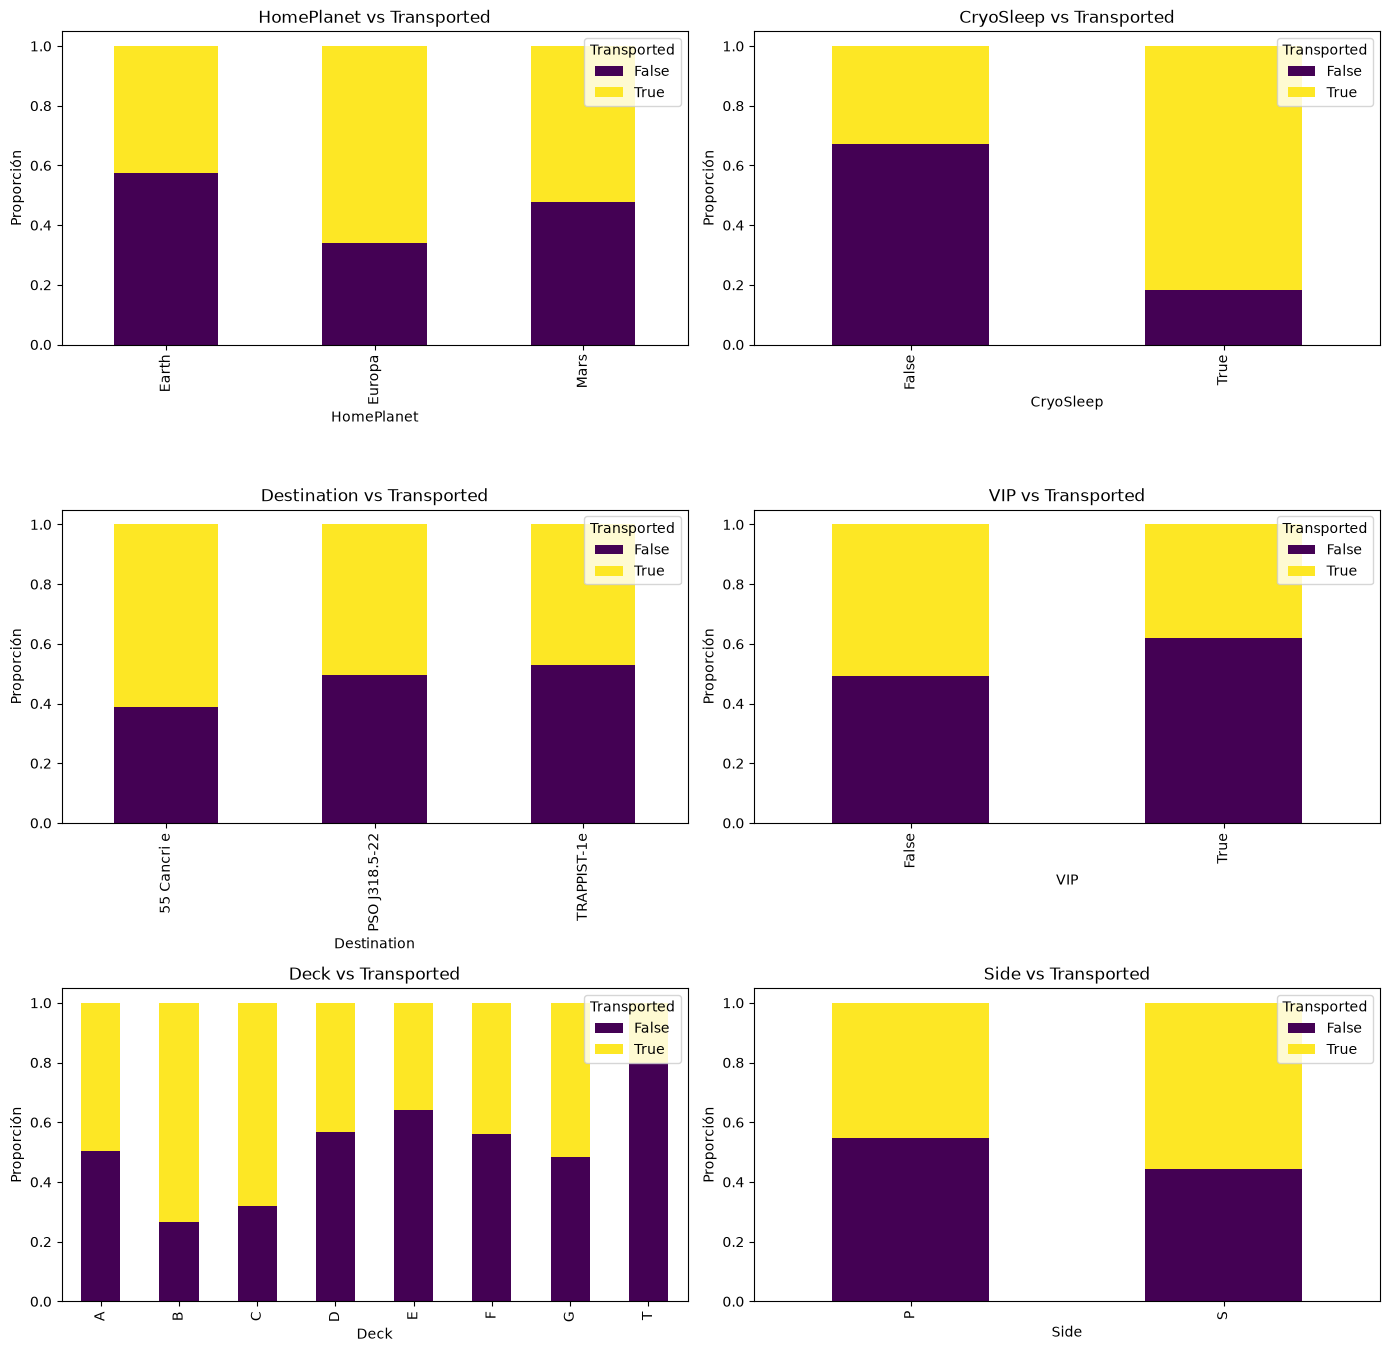

In [14]:
v_categoricas_crosstabs = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for i, col in enumerate(v_categoricas_crosstabs):
    ct = pd.crosstab(train[col], train['Transported'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    axes[i].set_title(f'{col} vs Transported')
    axes[i].set_ylabel('Proporción')
    axes[i].legend(title='Transported', loc='upper right')

for j in range(len(v_categoricas_crosstabs), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

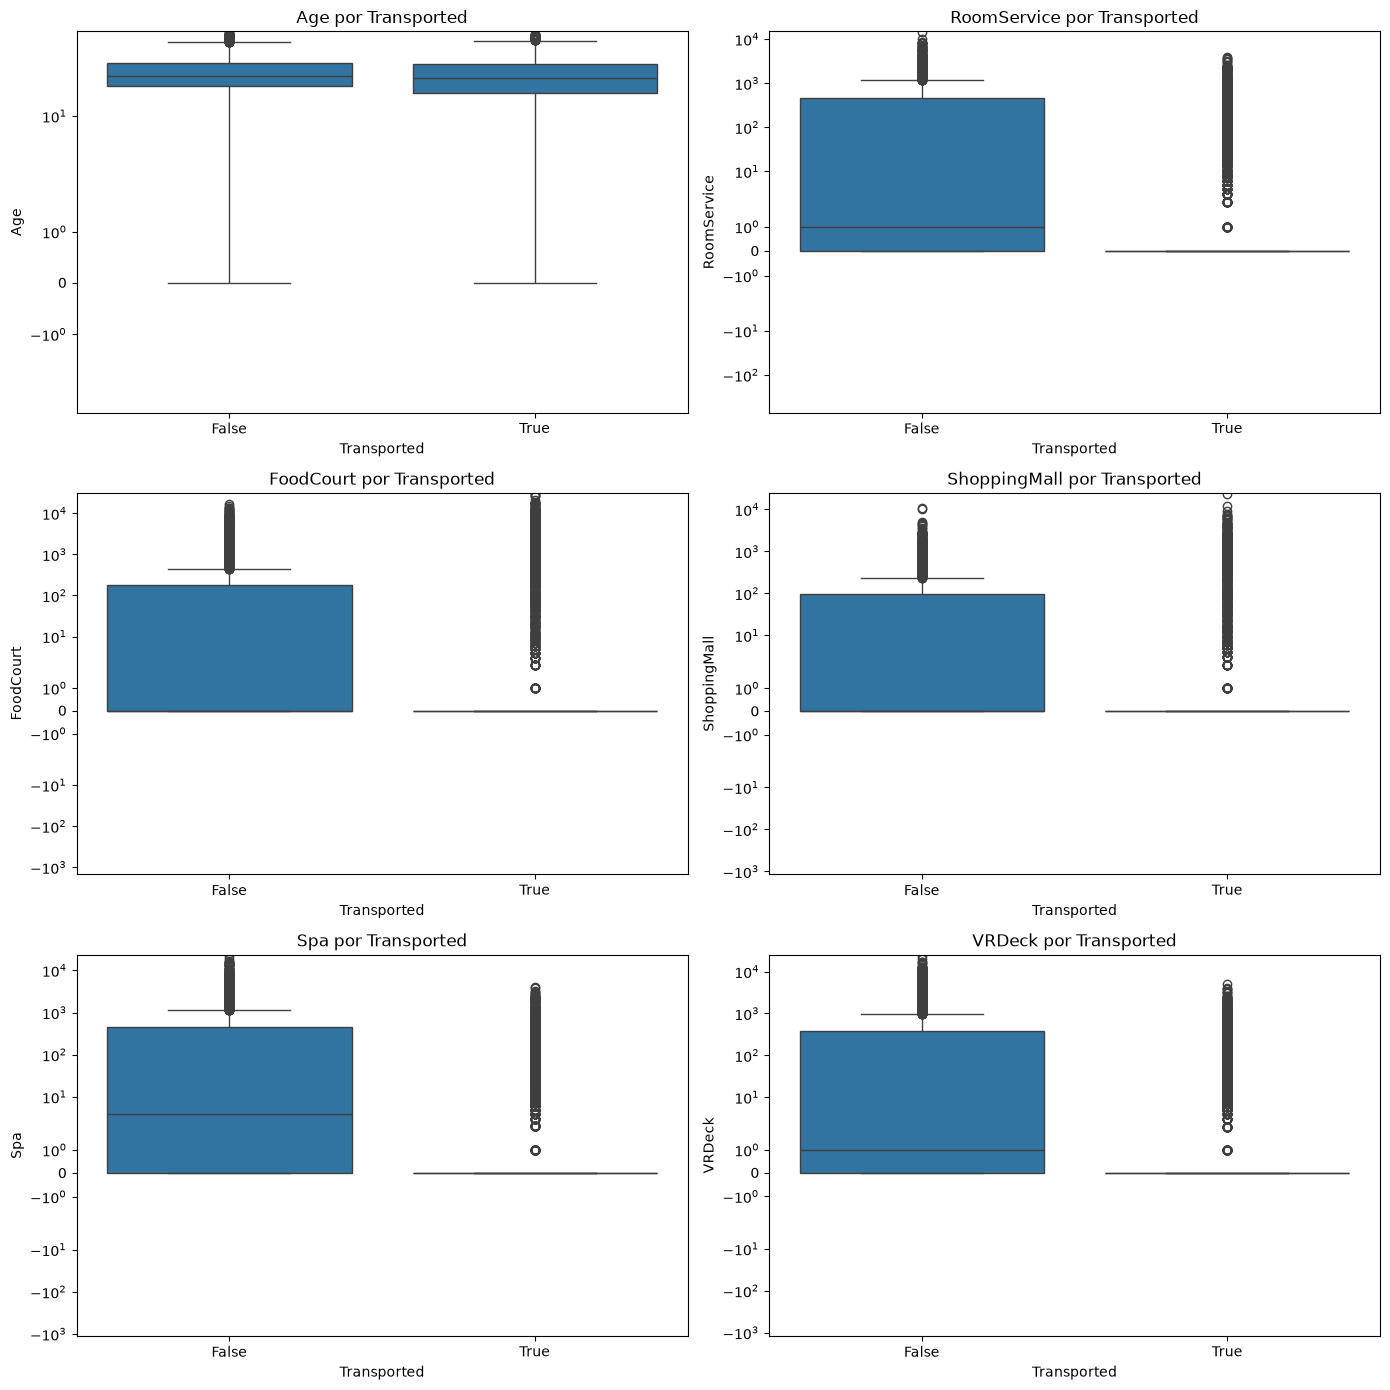

In [15]:
v_numericas = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(v_numericas):
    sns.boxplot(data=train, x='Transported', y=col, ax=axes[i])
    axes[i].set_title(f'{col} por Transported')
    axes[i].set_yscale('symlog')

plt.tight_layout()
plt.show()

## 3. Selección y descarte de variables

### 3.1 Variables incluidas en el pipeline

Listado de variables que se conservan para el modelado, con la evidencia del EDA que respalda cada inclusión (relación con el target, faltantes manejables, cardinalidad razonable, etc.).

In [16]:
v_conservar = [
    'HomePlanet',
    'CryoSleep',
    'Destination',
    'Deck',
    'Side',
    'NumCabin',
]

v_descartar = [
    'PassengerId',
    'Name',
    'Age',
    'VIP',
    'Cabin'
]

v_binarizar = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
]

Las seis variables que se conservan son las que muestran una separación visible en los crosstabs de la sección 2.4 y que además tienen una cardinalidad que el modelo puede manejar.

**CryoSleep** es la variable con la relación más fuerte con el target. En su crosstab la barra se parte casi en dos bloques distintos: la proporción de transportados entre los pasajeros dormidos está muy por encima de la de los pasajeros despiertos. Además solo tiene 2 categorías y 2.50% de faltantes, que son recuperables con la regla del gasto que ya validamos en la sección 2.1.

**HomePlanet** separa bien a los tres planetas. Europa queda arriba de la media, Earth abajo y Mars en medio, y la diferencia entre los extremos es grande. Con 3 categorías y 2.31% de faltantes, es de las variables más baratas de incluir.

**Destination** en la sección 2.1 la habíamos anotado como poco relevante, pero el crosstab muestra que 55 Cancri e tiene una proporción de transportados claramente mayor que TRAPPIST-1e. La diferencia es menor que la de CryoSleep, pero es consistente, y con 3 categorías y 2.09% de faltantes el costo de conservarla es mínimo. Se corrige entonces la anotación previa y la variable entra al pipeline.

**Deck** tiene 8 categorías y es la que más se benefició de haber descompuesto Cabin. Las cubiertas B y C están claramente arriba y E y F abajo, así que la variable aporta señal propia. La cubierta T casi no tiene pasajeros, pero eso no invalida al resto de las categorías.

**Side** solo tiene 2 categorías y la diferencia entre estribor y babor es pequeña, pero es limpia y constante. Con cardinalidad 2, incluirla cuesta una sola columna.

**NumCabin** tiene 1817 valores distintos, así que no se puede usar tal cual. Se conserva porque el número de cabina ordena físicamente las cabinas dentro de cada deck, y pasajeros con números cercanos viajaron juntos en la misma zona de la nave. Esperamos que esa vecindad conserve señal una vez agrupada en rangos, que es lo que se hace en la sección 5.2.

### 3.2 Variables descartadas

Listado de variables excluidas del pipeline, justificando cada descarte con evidencia concreta: porcentaje de faltantes, desbalance extremo, ausencia de relación con el target, cardinalidad excesiva o redundancia con otra variable.

**PassengerId** es un identificador y tiene tantos valores distintos como filas. La primera parte del id corresponde al grupo con el que viajó el pasajero y en principio podría explotarse, pero como columna directa no aporta nada y no se puede codificar. Se descarta.

**Name** tiene 2.30% de faltantes y es prácticamente único por pasajero, así que es la variable de mayor cardinalidad del dataset. No guarda relación con el target y cualquier codificación produciría miles de columnas vacías.

**Age** está limpia: solo 0.89% de outliers, muy por debajo del 20% de las variables de gasto, y 2.06% de faltantes. El problema es que no separa. En los boxplots de la sección 2.4 las cajas de Transported true y false quedan prácticamente encimadas, con la misma mediana, el mismo rango intercuartílico y bigotes casi idénticos. Es una variable limpia pero sin señal, así que se descarta.

**VIP** tiene desbalance extremo: menos del 3% de los pasajeros son VIP. Sobre una base tan chica, cualquier diferencia en la proporción de transportados es poco confiable, y en el crosstab la separación tampoco es grande. Sumando 2.34% de faltantes, no se justifica imputarla para conservar una columna casi constante.

**Cabin** se descarta como columna original porque ya quedó descompuesta en Deck, NumCabin y Side. Con 6560 valores distintos es inutilizable tal cual, y mantenerla junto a sus tres componentes sería pura redundancia.

In [17]:
# Por ahora, conservamos Passenger ID que puede ser útil para el match con el testing set, pero se descarta en el modelo final.
v_descartar = [
    'Name',
    'Age',
    'VIP',
    'Cabin'
]

train = train.drop(columns=v_descartar)

### 3.3 Evaluación de binarización para variables con desbalance extremo

Antes de descartar variables con clases muy desbalanceadas (por ejemplo, servicios de gasto a bordo), se evalúa si transformarlas en indicadores binarios (`HasPool`, `HasCabin`, etc.) preserva señal útil para el target.

Las cinco variables de gasto tienen más de 20% de outliers por IQR y un sesgo muy alto, pero eso no significa que no sirvan. Lo que probablemente separa a los pasajeros no es cuánto gastaron sino si gastaron algo, porque el gasto en cero es justamente la huella que deja CryoSleep. Antes de decidir si se descartan, comparamos la proporción de transportados entre los pasajeros que gastaron cero y los que gastaron más de cero en cada servicio.

In [18]:
resumen_bin = []

for col in v_binarizar:
    ind = train[col].fillna(0) > 0

    resumen_bin.append({
        'Variable': col,
        'Pasajeros con gasto': ind.sum(),
        'Transportados sin gasto': train.loc[~ind, 'Transported'].mean(),
        'Transportados con gasto': train.loc[ind, 'Transported'].mean()
    })

resumen_bin = pd.DataFrame(resumen_bin)

resumen_bin

,Variable,Pasajeros con gasto,Transportados sin gasto,Transportados con gasto
0,RoomService,2935,0.627822,0.259966
1,FoodCourt,3054,0.589289,0.345449
2,ShoppingMall,2898,0.596894,0.317115
3,Spa,3186,0.634465,0.277464
4,VRDeck,3010,0.624494,0.275415


La binarización sí conserva señal, y en varios servicios la separación es más fuerte que la de muchas variables categóricas. En RoomService, Spa y VRDeck los pasajeros que gastaron algo se transportan bastante menos que los que no gastaron nada, mientras que en FoodCourt y ShoppingMall la diferencia va en el otro sentido o es más suave. El corte en cero recupera casi toda la separación sin arrastrar el sesgo ni los outliers, así que cada variable de gasto se convierte en un indicador binario (UsoRoomService, UsoFoodCourt, UsoShoppingMall, UsoSpa y UsoVRDeck).

## 4. Manejo de faltantes

### 4.1 Imputación de faltantes informativos

Estrategia de imputación aplicada a las variables cuyo faltante fue clasificado como informativo en el paso 2.1 (por ejemplo, imputación condicionada al valor de otra variable relacionada), con su justificación.

| Variable | % Faltantes | Estrategia de imputación | Justificación |
|---|---|---|---|
| RoomService | 2.08% | 1) Si `CryoSleep == True` → imputar 0. 2) Si `CryoSleep == False` → imputar con la mediana de la columna calculada solo sobre pasajeros despiertos (`CryoSleep == False`). 3) Si `CryoSleep` también es faltante, se asume "despierto" (criterio conservador) y se aplica el paso 2. | El check de 2.1 confirmó que 0 de 4921 pasajeros en CryoSleep gastaron algo: el 0 es determinístico, no una estimación. La mediana condicionada evita contaminar la imputación con el pico de ceros que aportan los pasajeros dormidos. |
| FoodCourt | 2.11% | Misma regla que RoomService (pasos 1-3). |  |
| ShoppingMall | 2.39% | Misma regla que RoomService (pasos 1-3). |  |
| Spa | 2.11% | Misma regla que RoomService (pasos 1-3). |  |
| VRDeck | 2.16% | Misma regla que RoomService (pasos 1-3). |  |

### 4.2 Imputación de faltantes reales

Estrategia de imputación aplicada a las variables con faltantes reales (por ejemplo, medidas de tendencia central para numéricas o moda/categoría "Unknown" para categóricas), con su justificación.

| Variable | % Faltantes | Estrategia de imputación | Justificación |
|---|---|---|---|
| CryoSleep | 2.50% | 1) Si el gasto total (`RoomService+FoodCourt+ShoppingMall+Spa+VRDeck`) > 0 → `False` (regla determinística). 2) Si el gasto total es 0 o también falta → imputar con la moda global de `CryoSleep`. | El check de 2.1 valida el paso 1 en sentido inverso (gasto > 0 excluye CryoSleep=True). El paso 2 es un faltante genuino sin otra señal disponible una vez agotada la regla de gasto. |
| HomePlanet | 2.31% | 1) Imputar con la moda de `HomePlanet` condicionada al `Deck`. 2) Si el `Deck` también falta, usar la moda global. | El crosstab de 2.4 muestra que ciertos decks están asociados casi exclusivamente a un `HomePlanet`. No se usa `PassengerId` porque esa columna se descarta en la sección 3. |
| Destination | 2.09% | Imputar con la moda global (`TRAPPIST-1e`). | En 2.1 se concluyó que Destination no aporta señal relevante al target, por lo que no se justifica una imputación condicionada más compleja. |
| Deck | 2.29% (heredado de `Cabin`) | 1) Imputar con la moda de `Deck` condicionada a `HomePlanet` (ya imputado). 2) Si no hay dato, usar la moda global de `Deck`. | `Deck` está correlacionado con `HomePlanet` (evidencia de los crosstabs en 2.4). No se usa `PassengerId` porque esa columna se descarta en la sección 3. |
| Side | 2.29% (heredado de `Cabin`) | Imputar con la moda global de `Side`. | `Side` no mostró relación fuerte con el target en 2.4, por lo que basta la moda global. No se usa `PassengerId` porque esa columna se descarta en la sección 3. |
| NumCabin | 2.29% (heredado de `Cabin`) | Imputar con la mediana de `NumCabin` dentro del mismo `Deck` (ya imputado); si el `Deck` también es faltante, usar la mediana global. | Es una variable de alta cardinalidad pero con estructura por rangos dentro de cada deck; la mediana condicionada preserva mejor la posición relativa que una mediana global. |

### 4.3 Resumen de estrategia de imputación por variable

Tabla o resumen que consolida, por variable, el tipo de faltante y la estrategia de imputación elegida, evitando aplicar un único criterio genérico sin argumento.

| Variable | Tipo de faltante | Estrategia de imputación (resumen) | Justificación |
|---|---|---|---|
| CryoSleep | Real | Regla por gasto total (>0 → False); si no, moda global | Confirmada por el check de 2.1; sin otra señal disponible para el resto |
| HomePlanet | Real | Moda por `Deck` → moda global | Los decks comparten planeta de origen (2.4); no depende de `PassengerId` (se descarta en 3.2) |
| Destination | Real | Moda global (`TRAPPIST-1e`) | Sin relación con el target (2.1); no amerita imputación condicionada |
| Deck | Real (heredado de `Cabin`) | Moda por `HomePlanet` → moda global | Correlación con `HomePlanet` (2.4); no depende de `PassengerId` |
| Side | Real (heredado de `Cabin`) | Moda global | Sin relación fuerte con el target (2.4); no depende de `PassengerId` |
| NumCabin | Real (heredado de `Cabin`) | Mediana condicionada al `Deck` → mediana global | Alta cardinalidad con estructura por rangos dentro de cada deck |
| RoomService | Informativo | `CryoSleep`=True → 0; si no, mediana de despiertos | 0 de 4921 dormidos gastaron algo (check de 2.1) |
| FoodCourt | Informativo | Misma regla que RoomService | Misma dependencia estructural con `CryoSleep` |
| ShoppingMall | Informativo | Misma regla que RoomService |  |
| Spa | Informativo | Misma regla que RoomService |  |
| VRDeck | Informativo | Misma regla que RoomService |  |

In [19]:
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

gasto_total_original = train[spend_cols].sum(axis=1, skipna=True)

dormido = train["CryoSleep"] == True
despierto_o_faltante = train["CryoSleep"].fillna(False) == False

for col in spend_cols:
    mediana_despiertos = train.loc[despierto_o_faltante & train[col].notna(), col].median()
    falta = train[col].isna()
    train.loc[falta & dormido, col] = 0
    train.loc[falta & despierto_o_faltante, col] = mediana_despiertos

falta_cryo = train["CryoSleep"].isna()
train.loc[falta_cryo & (gasto_total_original > 0), "CryoSleep"] = False
train["CryoSleep"] = train["CryoSleep"].fillna(train["CryoSleep"].mode()[0])

def moda_por_grupo(serie):
    return serie.mode().iloc[0] if serie.notna().any() else np.nan

train["HomePlanet"] = train["HomePlanet"].fillna(
    train.groupby("Deck")["HomePlanet"].transform(moda_por_grupo)
)
train["HomePlanet"] = train["HomePlanet"].fillna(train["HomePlanet"].mode()[0])

train["Destination"] = train["Destination"].fillna(train["Destination"].mode()[0])

train["Deck"] = train["Deck"].fillna(
    train.groupby("HomePlanet")["Deck"].transform(moda_por_grupo)
)
train["Deck"] = train["Deck"].fillna(train["Deck"].mode()[0])

train["Side"] = train["Side"].fillna(train["Side"].mode()[0])

train["NumCabin"] = train["NumCabin"].fillna(
    train.groupby("Deck")["NumCabin"].transform("median")
)
train["NumCabin"] = train["NumCabin"].fillna(train["NumCabin"].median())

train.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Deck            0
NumCabin        0
Side            0
dtype: int64

In [20]:
# convertir indicadores binarios
spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for col in spend_cols:
    train[f"Uso{col}"] = (train[col] > 0).astype(int)

train = train.drop(columns=spend_cols)

## 5. Codificación de variables categóricas

### 5.1 Codificación de variables nominales

Aplicación de codificación a variables categóricas sin orden natural, justificando la elección según cardinalidad y naturaleza de cada variable.

In [21]:
train = pd.get_dummies(train, columns=['HomePlanet', 'Destination', 'Deck'], drop_first=True)
train['Side'] = train['Side'].map({'P': 0, 'S': 1})
train['CryoSleep'] = train['CryoSleep'].astype(int)

train

,PassengerId,CryoSleep,Transported,NumCabin,Side,UsoRoomService,UsoFoodCourt,UsoShoppingMall,UsoSpa,UsoVRDeck,...,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T
0,0001_01,0,False,0.0,0,0,0,0,0,0,...,False,False,True,True,False,False,False,False,False,False
1,0002_01,0,True,0.0,1,1,1,1,1,1,...,False,False,True,False,False,False,False,True,False,False
2,0003_01,0,False,0.0,1,1,1,0,1,1,...,False,False,True,False,False,False,False,False,False,False
3,0003_02,0,False,0.0,1,0,1,1,1,1,...,False,False,True,False,False,False,False,False,False,False
4,0004_01,0,True,1.0,1,1,1,1,1,1,...,False,False,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,0,False,98.0,0,0,1,0,1,1,...,False,False,False,False,False,False,False,False,False,False
8689,9278_01,1,False,1499.0,1,0,0,0,0,0,...,False,True,False,False,False,False,False,False,True,False
8690,9279_01,0,True,1500.0,1,0,0,1,1,0,...,False,False,True,False,False,False,False,False,True,False
8691,9280_01,0,False,608.0,1,0,1,0,1,1,...,False,False,False,False,False,False,True,False,False,False


### 5.2 Codificación de variables ordinales

Evaluación de si alguna variable categórica presenta orden natural y, de ser así, aplicación de una codificación ordinal justificada.

In [22]:
bins = [0, 300, 600, 900, 1200, 1500, 1800, train['NumCabin'].max()+1]
train['NumCabin_bin'] = pd.cut(train['NumCabin'], bins=bins, labels=False, include_lowest=True)
train

,PassengerId,CryoSleep,Transported,NumCabin,Side,UsoRoomService,UsoFoodCourt,UsoShoppingMall,UsoSpa,UsoVRDeck,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,NumCabin_bin
0,0001_01,0,False,0.0,0,0,0,0,0,0,...,False,True,True,False,False,False,False,False,False,0
1,0002_01,0,True,0.0,1,1,1,1,1,1,...,False,True,False,False,False,False,True,False,False,0
2,0003_01,0,False,0.0,1,1,1,0,1,1,...,False,True,False,False,False,False,False,False,False,0
3,0003_02,0,False,0.0,1,0,1,1,1,1,...,False,True,False,False,False,False,False,False,False,0
4,0004_01,0,True,1.0,1,1,1,1,1,1,...,False,True,False,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,0,False,98.0,0,0,1,0,1,1,...,False,False,False,False,False,False,False,False,False,0
8689,9278_01,1,False,1499.0,1,0,0,0,0,0,...,True,False,False,False,False,False,False,True,False,4
8690,9279_01,0,True,1500.0,1,0,0,1,1,0,...,False,True,False,False,False,False,False,True,False,4
8691,9280_01,0,False,608.0,1,0,1,0,1,1,...,False,False,False,False,False,True,False,False,False,2


### 5.3 Verificación de ausencia de columnas tipo `object`

Comprobación de que, tras la codificación, ninguna columna del dataset conserva el tipo `object`.

In [23]:
cols_object = train.drop(columns=['PassengerId']).select_dtypes(include='object').columns.tolist()
assert len(cols_object) == 0, f"Aún quedan columnas tipo object: {cols_object}"
train

,PassengerId,CryoSleep,Transported,NumCabin,Side,UsoRoomService,UsoFoodCourt,UsoShoppingMall,UsoSpa,UsoVRDeck,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,NumCabin_bin
0,0001_01,0,False,0.0,0,0,0,0,0,0,...,False,True,True,False,False,False,False,False,False,0
1,0002_01,0,True,0.0,1,1,1,1,1,1,...,False,True,False,False,False,False,True,False,False,0
2,0003_01,0,False,0.0,1,1,1,0,1,1,...,False,True,False,False,False,False,False,False,False,0
3,0003_02,0,False,0.0,1,0,1,1,1,1,...,False,True,False,False,False,False,False,False,False,0
4,0004_01,0,True,1.0,1,1,1,1,1,1,...,False,True,False,False,False,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,0,False,98.0,0,0,1,0,1,1,...,False,False,False,False,False,False,False,False,False,0
8689,9278_01,1,False,1499.0,1,0,0,0,0,0,...,True,False,False,False,False,False,False,True,False,4
8690,9279_01,0,True,1500.0,1,0,0,1,1,0,...,False,True,False,False,False,False,False,True,False,4
8691,9280_01,0,False,608.0,1,0,1,0,1,1,...,False,False,False,False,False,True,False,False,False,2


## 6. Transformación de variables numéricas

### 6.1 Evaluación del sesgo (skewness)

Revisión del coeficiente de asimetría de cada variable numérica para identificar cuáles presentan sesgo significativo.

In [24]:
v_continuas = ['NumCabin']

resumen_sesgo = pd.DataFrame({
    'Skewness': train[v_continuas].skew(),
    'Media': train[v_continuas].mean(),
    'Mediana': train[v_continuas].median(),
    'Maximo': train[v_continuas].max(),
    '% ceros': (train[v_continuas] == 0).mean() * 100
})

resumen_sesgo['Sesgo relevante'] = resumen_sesgo['Skewness'].abs() > 1

resumen_sesgo

,Skewness,Media,Mediana,Maximo,% ceros,Sesgo relevante
NumCabin,0.714676,600.452836,435.0,1894.0,0.207063,False


Solo se evalúan las variables continuas que quedaron vivas después de la sección 5. CryoSleep, Side y las dummies de HomePlanet, Destination y Deck son binarias: su asimetría refleja el desbalance de clases, no un sesgo corregible con una transformación, y aplicarles una sería tratarlas como magnitudes cuando solo son indicadores. NumCabin_bin tampoco entra porque es una codificación ordinal ya acotada a siete niveles, y PassengerId es identificador.

El criterio para marcar sesgo relevante es un valor absoluto de skewness mayor a 1, el umbral convencional para asimetría fuerte. Las cinco variables de gasto ya no aparecen en esta tabla: se convirtieron en indicadores binarios en la sección 3.3, justo después de la imputación de la sección 4 y antes de la codificación de la sección 5, así que nunca llegan a evaluarse aquí como continuas. La única variable evaluada es NumCabin, que se reparte de forma casi uniforme a lo largo de la nave y tiene una asimetría despreciable, así que no requiere transformación.

### 6.2 Aplicación de transformaciones justificadas

Aplicación de una transformación (p. ej. logarítmica o `PowerTransformer`) a las variables con sesgo relevante, justificando la elección según el tipo y grado de sesgo detectado.

Tras la binarización de la sección 3.3, ninguna variable queda marcada con sesgo relevante (`v_transformar` resulta una lista vacía): las cinco variables de gasto ya son indicadores 0/1 y NumCabin no supera el umbral de skewness definido en 6.1. Por lo tanto no hay nada que transformar ni que comparar entre log1p y Yeo-Johnson; la tabla de la celda siguiente queda vacía a propósito, como constancia de que el paso se evaluó y no aplica.

In [25]:
v_transformar = resumen_sesgo.index[resumen_sesgo['Sesgo relevante']].tolist()

if v_transformar:
    skew_log1p = np.log1p(train[v_transformar]).skew()

    yeo = PowerTransformer(method='yeo-johnson', standardize=False)
    skew_yeo = pd.DataFrame(
        yeo.fit_transform(train[v_transformar]),
        columns=v_transformar,
        index=train.index
    ).skew()

    comparacion_metodos = pd.DataFrame({
        'Skew original': train[v_transformar].skew(),
        'Skew log1p': skew_log1p,
        'Skew Yeo-Johnson': skew_yeo
    })
else:
    comparacion_metodos = pd.DataFrame(columns=['Skew original', 'Skew log1p', 'Skew Yeo-Johnson'])

comparacion_metodos


,Skew original,Skew log1p,Skew Yeo-Johnson


No se aplica ninguna transformación en esta sección: las cinco variables de gasto se convirtieron en indicadores binarios en la sección 3.3 y no necesitan corrección de sesgo, y NumCabin se deja sin transformar porque su asimetría ya es despreciable (6.1).

In [26]:
train_sin_transformar = train[v_transformar].copy()

train[v_transformar] = np.log1p(train[v_transformar])

resumen_transformacion = pd.DataFrame({
    'Skew original': train_sin_transformar.skew(),
    'Skew transformado': train[v_transformar].skew(),
    'Maximo original': train_sin_transformar.max(),
    'Maximo transformado': train[v_transformar].max(),
    '% ceros (se conserva)': (train[v_transformar] == 0).mean() * 100
})

resumen_transformacion

,Skew original,Skew transformado,Maximo original,Maximo transformado,% ceros (se conserva)


### 6.3 Comparación de distribuciones antes y después

Visualización comparativa (histogramas) de cada variable transformada, mostrando su distribución original frente a la distribución tras la transformación.

In [27]:
if v_transformar:
    fig, axes = plt.subplots(nrows=len(v_transformar), ncols=2,
                             figsize=(14, 3.2 * len(v_transformar)))

    for i, col in enumerate(v_transformar):
        axes[i, 0].hist(train_sin_transformar[col], bins=40,
                        color='#6C4FF6', edgecolor='white', alpha=0.85)
        axes[i, 0].set_title(f"{col} original (skew: {train_sin_transformar[col].skew():.2f})",
                             fontsize=11, fontweight='bold')
        axes[i, 0].set_xlabel(col)
        axes[i, 0].set_ylabel('Frecuencia')

        axes[i, 1].hist(train[col], bins=40,
                        color='#FFB020', edgecolor='white', alpha=0.85)
        axes[i, 1].set_title(f"{col} tras log1p (skew: {train[col].skew():.2f})",
                             fontsize=11, fontweight='bold')
        axes[i, 1].set_xlabel(f"log1p({col})")
        axes[i, 1].set_ylabel('Frecuencia')

    plt.tight_layout()
    plt.show()
else:
    print("No hay variables en v_transformar: nada que comparar antes/después.")

No hay variables en v_transformar: nada que comparar antes/después.


No hay histogramas que mostrar en esta sección: al no haber ninguna variable en `v_transformar` (las cinco variables de gasto quedaron binarizadas en 3.3, y NumCabin no necesitó transformación según 6.1), no existe una comparación antes/después que hacer. La celda de arriba queda vacía a propósito, como constancia de que el paso se evaluó.

## 7. Escalado

### 7.1 Selección del escalador según presencia de outliers

Decisión entre `StandardScaler` y `RobustScaler` (u otra alternativa) para cada grupo de variables numéricas, en función de la presencia de outliers detectada en el paso 2.2.

In [28]:
v_escalar = v_continuas + ['NumCabin_bin']

def pct_outliers(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        return np.nan
    return ((serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)).mean() * 100

diagnostico_escalado = pd.DataFrame({
    'Skew': train[v_escalar].skew(),
    '% outliers IQR': [pct_outliers(train[col]) for col in v_escalar],
    'Media': train[v_escalar].mean(),
    'Mediana': train[v_escalar].median(),
    'Min': train[v_escalar].min(),
    'Max': train[v_escalar].max()
})

diagnostico_escalado

,Skew,% outliers IQR,Media,Mediana,Min,Max
NumCabin,0.714676,0.0,600.452836,435.0,0.0,1894.0
NumCabin_bin,0.768610,0.0,1.522259,1.0,0.0,6.0


El diagnóstico se recalcula después de transformar, no sobre los valores originales: escalar es el último paso y lo que importa es la forma que tienen las variables al llegar a él, no la que tenían en la sección 2.2.

Las cinco variables de gasto no aparecen en este diagnóstico ni en el escalado: quedaron como indicadores binarios (UsoRoomService, UsoFoodCourt, UsoShoppingMall, UsoSpa, UsoVRDeck) tras la binarización de la sección 3.3, fuera de `v_continuas`.

A NumCabin y NumCabin_bin, que describen la posición del pasajero dentro de la nave, se les aplica StandardScaler. Sus distribuciones son casi uniformes y sin outliers por IQR: NumCabin no tiene sesgo relevante según 6.1, y NumCabin_bin tampoco según la tabla diagnóstica de esta misma sección — es exactamente el escenario para el que StandardScaler es el escalador correcto: no hay cola que distorsione la media ni la desviación estándar.

Las variables binarias, es decir CryoSleep, Side, los indicadores UsoRoomService, UsoFoodCourt, UsoShoppingMall, UsoSpa y UsoVRDeck, y las dummies de HomePlanet, Destination y Deck, no se escalan. Ya están en cero y uno, que es un rango comparable al de las demás variables una vez escaladas. Estandarizarlas destruiría la interpretación directa de la dummy y desplazaría el cero a un valor negativo sin ninguna ganancia.

PassengerId y Transported quedan fuera del escalado: la primera es identificador y la segunda es el target.

### 7.2 Aplicación del escalado

Ajuste y aplicación del escalador elegido sobre las variables numéricas del dataset, con justificación de la elección.

In [29]:
v_robust = v_transformar
v_standard = [col for col in v_escalar if col not in v_robust]

robust_scaler = RobustScaler()
standard_scaler = StandardScaler()

if v_robust:
    train[v_robust] = robust_scaler.fit_transform(train[v_robust])
if v_standard:
    train[v_standard] = standard_scaler.fit_transform(train[v_standard])

print('RobustScaler  ->', v_robust)
print('StandardScaler ->', v_standard)

train[v_escalar].describe().T

RobustScaler  -> []
StandardScaler -> ['NumCabin', 'NumCabin_bin']


,count,mean,std,min,25%,50%,75%,max
NumCabin,8693.0,-1.046238e-16,1.000058,-1.182073,-0.855279,-0.325716,0.753096,2.546523
NumCabin_bin,8693.0,0.000000e+00,1.000058,-0.912832,-0.912832,-0.313176,0.886136,2.685104


Los escaladores se ajustan con fit únicamente sobre train. Los objetos robust_scaler y standard_scaler quedan guardados para poder aplicar sobre test exactamente los mismos centros y escalas con transform, sin volver a ajustar: reajustarlos sobre test produciría dos espacios de variables distintos y filtraría información del conjunto de prueba.

Las variables de gasto no pasan por ningún escalador: tras la binarización de 3.3 quedan como indicadores UsoRoomService, UsoFoodCourt, UsoShoppingMall, UsoSpa y UsoVRDeck, ya en el mismo rango 0/1 que el resto de las variables binarias. En NumCabin y NumCabin_bin la media queda en cero y la desviación estándar en uno, como corresponde al StandardScaler.

## 8. Verificación final

### 8.1 Confirmación de ausencia de nulos

Comprobación de que el conjunto de datos procesado no contiene valores nulos.

In [30]:
# PassengerId ya cumplió su propósito (emparejar con test.csv durante el preprocesamiento) y no aporta señal al modelo.
train = train.drop(columns=['PassengerId'])

In [31]:
nulos = train.isnull().sum()
nulos

CryoSleep                    0
Transported                  0
NumCabin                     0
Side                         0
UsoRoomService               0
UsoFoodCourt                 0
UsoShoppingMall              0
UsoSpa                       0
UsoVRDeck                    0
HomePlanet_Europa            0
HomePlanet_Mars              0
Destination_PSO J318.5-22    0
Destination_TRAPPIST-1e      0
Deck_B                       0
Deck_C                       0
Deck_D                       0
Deck_E                       0
Deck_F                       0
Deck_G                       0
Deck_T                       0
NumCabin_bin                 0
dtype: int64

### 8.2 Confirmación de ausencia de columnas tipo `object`

Comprobación de que todas las columnas del dataset final son de tipo numérico.

In [32]:
train.dtypes

CryoSleep                      int64
Transported                     bool
NumCabin                     float64
Side                           int64
UsoRoomService                 int64
UsoFoodCourt                   int64
UsoShoppingMall                int64
UsoSpa                         int64
UsoVRDeck                      int64
HomePlanet_Europa               bool
HomePlanet_Mars                 bool
Destination_PSO J318.5-22       bool
Destination_TRAPPIST-1e         bool
Deck_B                          bool
Deck_C                          bool
Deck_D                          bool
Deck_E                          bool
Deck_F                          bool
Deck_G                          bool
Deck_T                          bool
NumCabin_bin                 float64
dtype: object

### 8.3 Shape final del dataset procesado

Reporte de la dimensión final (filas x columnas) del dataset tras todas las transformaciones.

In [33]:
train.shape

(8693, 21)

### 8.4 Tabla resumen de decisiones

Tabla que consolida, para cada variable original: tipo de variable, tratamiento aplicado (imputación, codificación, transformación, escalado o descarte) y justificación de la decisión.

| Variable | Tipo | Tratamiento | Justificacion |
|---|---|---|---|
| PassengerId | String, identificador único | Se conserva durante el preprocesamiento para emparejar con test.csv; se descarta al inicio de la sección 8 (verificación final) | Tiene tantos valores únicos como filas; no aporta señal y no es codificable de forma útil |
| HomePlanet | Categórica nominal| Imputación: moda condicionada a Deck, luego moda global. Codificación: one-hot | Separa claramente la proporción de transportados entre Europa, Earth y Mars. Los decks comparten HomePlanet, lo que sustenta la imputación condicionada |
| CryoSleep | Bool | Imputación: regla determinística por gasto total. Codificación: cast a entero | Es la variable con la relación más fuerte con el target, el check de la sección 2.1 confirmó que ningún pasajero dormido gastó, validando la regla |
| Cabin | Categórica compuesta | Descarte de la columna original tras descomponerla en Deck, NumCabin y Side | Inutilizable tal cual por su cardinalidad; mantenerla junto a sus componentes sería redundante |
| Deck | Categórica nominal (derivada de Cabin) | Imputación: moda condicionada a HomePlanet, luego moda global. Codificación: one-hot (drop_first) | Cubiertas B/C quedan claramente arriba y E/F abajo en proporción de transportados (2.4); correlaciona con HomePlanet, lo que sustenta la imputación condicionada |
| Side | Categórica binaria (derivada de Cabin) | Imputación: moda global. Codificación: mapeo binario (P=0, S=1) | Diferencia pequeña pero consistente en el crosstab de 2.4; con cardinalidad 2 no amerita one-hot |
| NumCabin | Numérica continua (derivada de Cabin) | Imputación: mediana condicionada a Deck, luego mediana global. Sin transformación (skew despreciable, 6.1). Escalado: StandardScaler. Se deriva además NumCabin_bin (binning en 7 rangos), también escalada con StandardScaler | Alta cardinalidad (1817 valores), pero ordena físicamente las cabinas dentro de cada deck; se espera que la vecindad conserve señal una vez agrupada en rangos (5.2) |
| Destination | Categórica nominal | Imputación: moda global. Codificación: one-hot | En 2.1 se había anotado como poco relevante, pero el crosstab de 2.4 mostró una diferencia consistente; se corrigió la anotación y se conservó |
| Age | Numérica continua | Descarte | Baja tasa de outliers (0.89%) y faltantes (2.06%), pero los boxplots de 2.4 muestran distribuciones prácticamente idénticas entre Transported true/false: no aporta señal  |
| VIP | Bool | Descarte | Desbalance extremo (<3% VIP), la diferencia en proporción de transportados no es confiable sobre una base tan chica, no se justifica imputar el 2.34% de faltantes |
| RoomService | Categórica binaria derivada | Imputación informativa condicionada a CryoSleep, luego se convierte en el indicador `UsoRoomService` = (gasto > 0) (binarización de 3.3, aplicada en la sección 4). Sin transformación ni escalado | La sección 3.3 muestra que la señal está en gastar o no, no en el monto; el indicador preserva esa separación sin arrastrar el sesgo ni los outliers |
| FoodCourt | Categórica binaria derivada | Misma regla que RoomService: indicador `UsoFoodCourt` = (gasto > 0). Sin transformación ni escalado | Misma dependencia estructural con CryoSleep y mismo tratamiento que RoomService |
| ShoppingMall | Categórica binaria derivada | Misma regla que RoomService: indicador `UsoShoppingMall` = (gasto > 0). Sin transformación ni escalado | Misma dependencia estructural con CryoSleep |
| Spa | Categórica binaria derivada | Misma regla que RoomService: indicador `UsoSpa` = (gasto > 0). Sin transformación ni escalado | Misma dependencia estructural con CryoSleep |
| VRDeck | Categórica binaria derivada | Misma regla que RoomService: indicador `UsoVRDeck` = (gasto > 0). Sin transformación ni escalado | Misma dependencia estructural con CryoSleep |
| Name | String, identificador casi único | Descarte | 2.30% de faltantes, cardinalidad más alta del dataset, sin relación con el target, cualquier codificación generaría miles de columnas casi vacías |
| Transported | Bool | Sin tratamiento | Es la variable a predecir, define el problema como clasificación binaria supervisada |

### 8.5 Conclusiones y hallazgos

El EDA mostró que los faltantes del dataset no son homogéneos: una parte (CryoSleep, HomePlanet, Destination, Age, VIP, Name, Cabin) son faltantes reales de captura, mientras que las cinco variables de gasto y, por herencia, parte de Cabin (Deck, Side, NumCabin) tienen un componente informativo ligado al estado de CryoSleep, confirmado con el check de 2.1 (ningún pasajero dormido registró gasto). Esta distinción fue la base de las estrategias de imputación: reglas determinísticas y condicionadas (por Deck, por HomePlanet, por CryoSleep) en lugar de un único criterio genérico, lo que preserva mejor la estructura de los datos que imputar con la moda o mediana global desde el inicio.

En la selección de variables, CryoSleep se confirmó como el predictor individual más fuerte, seguido de HomePlanet y Deck; Destination y Side aportan una señal más débil pero consistente, y NumCabin se conserva por su capacidad de capturar cercanía física dentro de cada deck una vez agrupada en rangos. En contraste, Age, VIP, Name, PassengerId y Cabin (como columna original) se descartaron por falta de relación con el target, desbalance extremo o cardinalidad inmanejable. El hallazgo más relevante de la sección 3.3 es que las variables de gasto no aportan por su magnitud sino por el simple hecho de haber gastado o no: por eso, en el pipeline final, RoomService, FoodCourt, ShoppingMall, Spa y VRDeck se tratan como indicadores binarios (UsoRoomService, UsoFoodCourt, UsoShoppingMall, UsoSpa, UsoVRDeck) y no como variables numéricas continuas, lo cual evita tener que aplicarles una transformación de sesgo o un escalador.

En conjunto, las decisiones de las secciones 2 a 5 dejan un conjunto reducido y justificado de variables (HomePlanet, CryoSleep, Destination, Deck, Side, NumCabin, y los cinco indicadores de uso) sin nulos y ya codificadas numéricamente, lo que deja al modelo trabajar sobre una base limpia y con señal verificada respecto al target, en lugar de depender de imputaciones o codificaciones aplicadas sin evidencia del EDA.

## 9. Corrección del planteamiento y preparación para el modelado

En la sección 1.3 se afirmó que test.csv contiene valores de Transported y que eso permitiría verificar las respuestas del modelo. Es incorrecto, ya que el archivo test.csv de la competencia de Kaggle no incluye la columna Transported, precisamente porque es el archivo de submission y las etiquetas son la respuesta que la competencia mantiene oculta. Sin etiquetas no existe forma de calcular accuracy, precision, recall ni ninguna otra métrica sobre ese conjunto.

La corrección es dividir train.csv, que sí está etiquetado, en dos particiones: una de entrenamiento y una de prueba. El split se hace estratificado por Transported para que ambas particiones conserven la misma proporción de clases que el dataset completo, y con una semilla fija para que todos los integrantes del equipo trabajen exactamente sobre las mismas filas en la sección 13.

### 9.1 Separación en variables predictoras y target

Transported se separa del resto de las columnas y se convierte a entero (0/1). El resto del DataFrame conforma la matriz de predictoras X.

In [34]:
X = train.drop(columns=['Transported'])
y = train['Transported'].astype(int)

print('X:', X.shape)
print('y:', y.shape)
print()
print('Proporción de clases en y:')
print(y.value_counts(normalize=True).rename({0: 'No transportado', 1: 'Transportado'}))

X: (8693, 20)
y: (8693,)

Proporción de clases en y:
Transported
Transportado       0.503624
No transportado    0.496376
Name: proportion, dtype: float64


### 9.2 División en train y test

Se reserva el 20% de las observaciones como conjunto de prueba. Sobre esa partición no se entrena ningún modelo: sirve exclusivamente para estimar el desempeño en datos que el modelo no vio, que es lo que se reporta en las secciones 11 y 12.



In [35]:
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('X_train:', X_train.shape, '| y_train:', y_train.shape)
print('X_test: ', X_test.shape, '| y_test: ', y_test.shape)

X_train: (6954, 20) | y_train: (6954,)
X_test:  (1739, 20) | y_test:  (1739,)


In [36]:
comparacion_split = pd.DataFrame({
    'Dataset completo': y.value_counts(normalize=True),
    'Train': y_train.value_counts(normalize=True),
    'Test': y_test.value_counts(normalize=True)
})
comparacion_split.index = ['No transportado', 'Transportado']

comparacion_split

,Dataset completo,Train,Test
No transportado,0.503624,0.503595,0.503738
Transportado,0.496376,0.496405,0.496262


El dataset procesado llega al modelado sin nulos y con todas sus columnas en tipo numérico, que era la condición de salida de la preparación de datos. Las columnas son las seis variables conservadas en la sección 3.1, ya codificadas: CryoSleep, Side, NumCabin, NumCabin_bin y las dummies de HomePlanet, Destination y Deck, más los cinco indicadores de uso de servicios creados en la sección 3.3.

El target está prácticamente balanceado, cerca de un 50/50 entre transportados y no transportados. Esto tiene dos consecuencias directas para lo que sigue: el accuracy es una métrica legible en este problema, porque no puede inflarse prediciendo siempre la clase mayoritaria, y no hace falta aplicar técnicas de rebalanceo ni pesos por clase en el entrenamiento. La justificación completa de las métricas se desarrolla en la sección 10.

El split estratificado conserva esa proporción en las tres particiones, como confirma la tabla anterior. Con X_train, X_test, y_train y y_test definidos, el resto del trabajo ya tiene sobre qué entrenar y contra qué evaluar.

## 10. Selección de métricas

La elección de métricas parte de dos características del dataset.

La primera es que el target está balanceado: 50.4% de pasajeros transportados contra 49.6% no transportados. Esto es determinante porque el problema clásico del accuracy, que un modelo que siempre predice la clase mayoritaria alcance un valor alto y aun así sea inútil, no puede ocurrir aquí. Con las clases repartidas casi a la mitad, el accuracy sí refleja capacidad real de discriminación y puede usarse como criterio de comparación.

La segunda es que el problema no tiene un costo asimétrico entre los dos tipos de error. En los ejemplos habituales hay una clase de interés cuyo error duele más: no detectar una enfermedad es peor que una falsa alarma, y marcar un correo legítimo como spam es peor que dejar pasar spam. Aquí las dos clases son simétricas: predecir que un pasajero fue transportado cuando no lo fue no es ni más ni menos grave que lo contrario. No hay entonces motivo para optimizar recall o precision por separado, y ambas se reportan como herramienta de diagnóstico, no como criterio de decisión.

| Métrica | Qué responde | Por qué se usa aquí |
|---|---|---|
| Accuracy | De todas las predicciones, qué fracción se acertó | Es legible porque las clases están balanceadas; es la métrica principal de comparación |
| Precision | De los que predije como transportados, cuántos lo eran | Diagnostica los falsos positivos |
| Recall | De los transportados reales, cuántos encontré | Diagnostica los falsos negativos |
| Specificity | De los no transportados reales, cuántos clasifiqué bien | Es el equivalente del recall sobre la clase negativa; junto con recall muestra el comportamiento en ambas clases con la misma resolución |
| F1-score | Media armónica de precision y recall | Resume ambas en un número para la tabla comparativa de la sección 12; no es criterio principal porque su ventaja aplica a datos desbalanceados |
| ROC-AUC | Qué tan bien separa las clases en general | No depende del umbral de 0.5, así que dos modelos con el mismo accuracy pueden distinguirse aquí; es el segundo criterio de comparación |

Se reporta además la matriz de confusión de cada modelo, porque es la base de la que salen todas las métricas anteriores y porque la pregunta de qué tipo de error comete más el modelo se responde directamente comparando sus dos celdas de error.

El criterio de comparación de la sección 12 será accuracy y ROC-AUC de manera conjunta: la primera mide el acierto al umbral por defecto y la segunda la calidad del ordenamiento con independencia del umbral. Las demás métricas sirven para argumentar el comportamiento de cada modelo, no para rankearlos.

Se define una función única que calcula todas las métricas elegidas. Specificity no existe como función en scikit-learn, así que se calcula a partir de la matriz de confusión como la proporción de negativos reales clasificados como negativos.

In [37]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

def evaluar_modelo(nombre, y_real, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()

    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_real, y_pred),
        'Precision': precision_score(y_real, y_pred, zero_division=0),
        'Recall': recall_score(y_real, y_pred, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'F1': f1_score(y_real, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_real, y_proba),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }

#acumulador de resultados para la tabla comparativa de la sección 12
resultados = []

In [38]:
#calculo de baseline con el modelo DummyClassifier

baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)
y_proba_baseline = baseline.predict_proba(X_test)[:, 1]

res_baseline = evaluar_modelo('Baseline (clase mayoritaria)',
                              y_test, y_pred_baseline, y_proba_baseline)
resultados.append(res_baseline)

pd.DataFrame([res_baseline]).round(4)

,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Baseline (clase mayoritaria),0.5037,0.5037,1.0,0.0,0.67,0.5,0,863,0,876


In [39]:
print('Clase que predice siempre el baseline:', baseline.predict(X_test[:1])[0])
print()
print(f"Accuracy del baseline: {res_baseline['Accuracy']:.4f}")
print(f"ROC-AUC del baseline:  {res_baseline['ROC-AUC']:.4f}")

Clase que predice siempre el baseline: 1

Accuracy del baseline: 0.5037
ROC-AUC del baseline:  0.5000


El marca el mínimo (0.5037). Ya que el baseline predice siempre la clase mayoritaria, que en este dataset es Transportado, y acierta en la misma proporción en que esa clase aparece en el conjunto de prueba. Cualquier modelo que no supere ese 50.37% de accuracy no está aprendiendo nada de las variables.

El resto de las métricas del baseline muestra por qué ninguna sirve por sí sola:

Recall: 1.0, el máximo posible. El modelo encuentra al 100% de los transportados por la vía trivial de decir que todos lo fueron. Un recall perfecto no significa nada si no se lee junto con la specificity.


Specificity: 0.0, el mínimo posible. No clasifica correctamente a ni un solo pasajero no transportado. Recall y specificity en extremos opuestos es exactamente la firma de un modelo degenerado, y es la razón por la que se reportan las dos.


F1 score: 0.67, un número que parece razonable y proviene de un modelo inútil. Esto justifica la decisión de la sección 10 de no usar F1 como criterio principal; la media armónica se deja arrastrar por el recall perfecto.


ROC-AUC: 0.5, que es el valor de un modelo aleatorio. Es la métrica que delata al baseline sin ambigüedad, porque el clasificador asigna la misma probabilidad a todos los pasajeros y por lo tanto no los ordena de ninguna forma.


Los umbrales a superar quedan entonces en 0.5037 de accuracy y 0.5 de ROC-AUC.

## 11. Entrenamiento de modelos

### 11.1 Árbol de decisión

El conjunto procesado quedó formado casi enteramente por variables binarias, los indicadores de uso de servicios, las dummies de HomePlanet, Destination y Deck, y CryoSleep y Side, con solo dos columnas continuas. El árbol trabaja con umbrales y no con distancias, así que maneja esa mezcla sin problema y además es indiferente al escalado. Es también el modelo más interpretable disponible, lo que permite responder dónde falla mirando su estructura y no solo sus métricas.

**Hiperparámetros iniciales:**

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| max_depth | 5 | Es el hiperparámetro más importante del árbol y el criterio de referencia es empezar entre 3 y 5. Sin límite de profundidad el árbol crece hasta la pureza y sobreajusta agresivamente, que es su desventaja principal. Se toma el extremo superior del rango recomendado para dar margen a que el modelo combine varias variables antes de decidir, sin llegar a memorizar. |
| criterion | gini | Es el valor por defecto para clasificación y el criterio de impureza estándar. Cambiarlo a entropy sin una razón previa introduciría una variable más en la comparación. |
| min_samples_split | 2 (default) | Se deja en el valor por defecto porque max_depth ya está controlando el crecimiento del árbol. Restringir dos cosas a la vez impediría atribuir el resultado a una u otra. |
| min_samples_leaf | 1 (default) | Mismo criterio que el anterior. |
| random_state | 42 | El árbol es sensible a pequeños cambios en los datos, y ante empates entre splits la elección depende del generador aleatorio. Fijarlo hace el resultado reproducible. |

Tambien se implementara una optimizacion al arbol utilizando gridsearch con el proposito de tener una comparacion directa entre un arbol de decision con hiperparametros manualmente seleccionados, y un arbol de decision con los mejores hiperparametros posibles.

In [40]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV

arbol = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    random_state=RANDOM_STATE
)

param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=arbol,
    param_grid=param_grid,
    scoring='roc_auc',   # o 'f1', 'recall', 'accuracy' según lo que te importe más
    cv=5,                # validación cruzada de 5 folds
    n_jobs=-1,           # usa todos los núcleos disponibles
    verbose=1
)

# Ajustar sobre datos de entrenamiento
grid_search.fit(X_train, y_train)

# Ver los mejores hiperparámetros y el mejor score
print('Mejores hiperparámetros:', grid_search.best_params_)
print('Mejor score (CV):', grid_search.best_score_)

# Extraer el mejor modelo ya entrenado
mejor_arbol = grid_search.best_estimator_

# Evaluarlo igual que hiciste con el árbol original
y_pred_mejor = mejor_arbol.predict(X_test)
y_proba_mejor = mejor_arbol.predict_proba(X_test)[:, 1]

res_mejor_arbol = evaluar_modelo(
    'Árbol de decisión (GridSearch)',
    y_test, y_pred_mejor, y_proba_mejor
)
resultados.append(res_mejor_arbol)

pd.DataFrame(resultados).round(4)


Fitting 5 folds for each of 768 candidates, totalling 3840 fits
Mejores hiperparámetros: {'criterion': 'gini', 'max_depth': 6, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Mejor score (CV): 0.8067143282308002


,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.0000,0.6700,0.5000,0,863,0,876
1,Árbol de decisión (GridSearch),0.7614,0.8029,0.6975,0.8262,0.7465,0.8196,713,150,265,611


In [41]:
arbol.fit(X_train, y_train)

print('Modelo entrenado')
print('Profundidad alcanzada:', arbol.get_depth())
print('Número de hojas:', arbol.get_n_leaves())

Modelo entrenado
Profundidad alcanzada: 5
Número de hojas: 32


In [42]:
y_pred_arbol = arbol.predict(X_test)
y_proba_arbol = arbol.predict_proba(X_test)[:, 1]

res_arbol = evaluar_modelo('Árbol de decisión (max_depth=5)',
                           y_test, y_pred_arbol, y_proba_arbol)
resultados.append(res_arbol)

pd.DataFrame(resultados).round(4)

,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.0000,0.6700,0.5000,0,863,0,876
1,Árbol de decisión (GridSearch),0.7614,0.8029,0.6975,0.8262,0.7465,0.8196,713,150,265,611
2,Árbol de decisión (max_depth=5),0.7539,0.8011,0.6804,0.8285,0.7358,0.8179,715,148,280,596


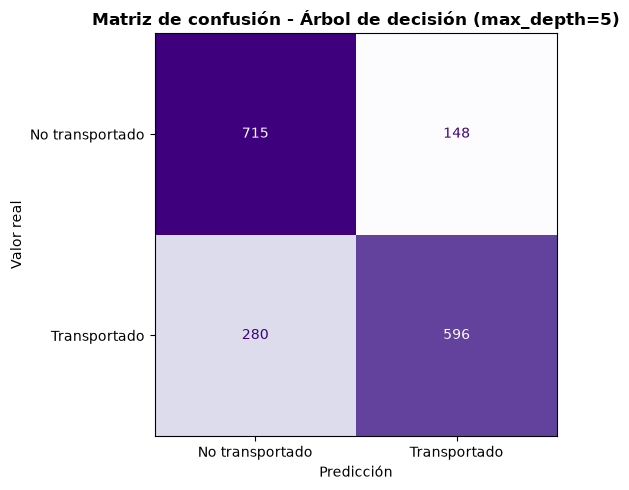

Falsos negativos (transportados no detectados): 280
Falsos positivos (no transportados marcados como transportados): 148


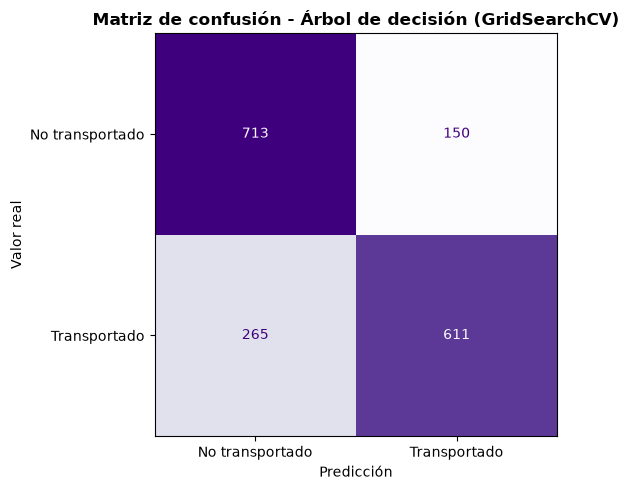

Falsos negativos (transportados no detectados): 265
Falsos positivos (no transportados marcados como transportados): 150


In [43]:
#Display de la matriz de confusión para el árbol de decisión con max_depth=5
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_arbol,
    display_labels=['No transportado', 'Transportado'],
    cmap='Purples',
    colorbar=False,
    ax=ax
)

ax.set_title('Matriz de confusión - Árbol de decisión (max_depth=5)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')

plt.tight_layout()
plt.show()

print(f"Falsos negativos (transportados no detectados): {res_arbol['FN']}")
print(f"Falsos positivos (no transportados marcados como transportados): {res_arbol['FP']}")

#Display de la matriz de confusión para el mejor árbol encontrado por GridSearchCV
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mejor,
    display_labels=['No transportado', 'Transportado'],
    cmap='Purples',
    colorbar=False,
    ax=ax
)

ax.set_title('Matriz de confusión - Árbol de decisión (GridSearchCV)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')

plt.tight_layout()
plt.show()

print(f"Falsos negativos (transportados no detectados): {res_mejor_arbol['FN']}")
print(f"Falsos positivos (no transportados marcados como transportados): {res_mejor_arbol['FP']}")

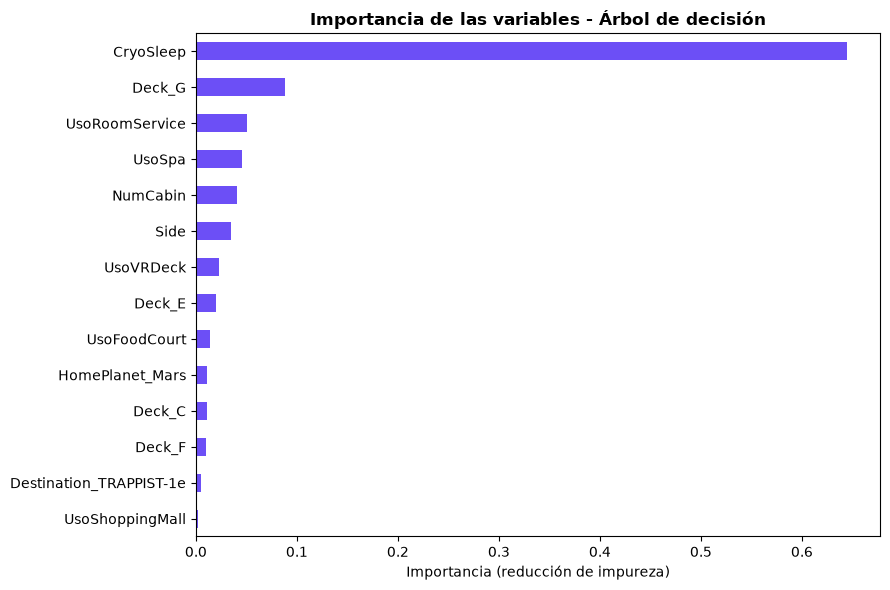

Variables no utilizadas por el árbol:
['Destination_PSO J318.5-22', 'HomePlanet_Europa', 'Deck_D', 'Deck_B', 'Deck_T', 'NumCabin_bin']


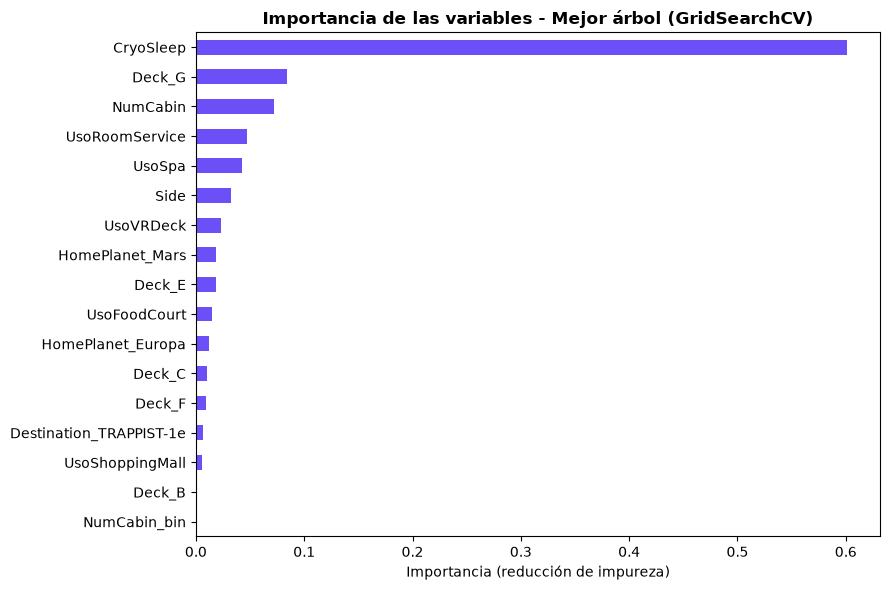

Variables no utilizadas por el mejor árbol:
['Destination_PSO J318.5-22', 'Deck_D', 'Deck_T']


In [44]:
importancias = pd.Series(arbol.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
importancias[importancias > 0].sort_values().plot(kind='barh', ax=ax, color='#6C4FF6')
ax.set_title('Importancia de las variables - Árbol de decisión',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia (reducción de impureza)')
plt.tight_layout()
plt.show()

print('Variables no utilizadas por el árbol:')
print(importancias[importancias == 0].index.tolist())

#Importancia de variables para el mejor árbol encontrado por GridSearchCV
importancias_mejor = pd.Series(mejor_arbol.feature_importances_, index=X_train.columns)
importancias_mejor = importancias_mejor.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
importancias_mejor[importancias_mejor > 0].sort_values().plot(kind='barh', ax=ax, color='#6C4FF6')
ax.set_title('Importancia de las variables - Mejor árbol (GridSearchCV)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia (reducción de impureza)')
plt.tight_layout()
plt.show()

print('Variables no utilizadas por el mejor árbol:')
print(importancias_mejor[importancias_mejor == 0].index.tolist())

In [45]:
from sklearn.tree import export_text

print(export_text(arbol, feature_names=list(X_train.columns), max_depth=2))
print(export_text(mejor_arbol, feature_names=list(X_train.columns), max_depth=2))

|--- CryoSleep <= 0.50
|   |--- UsoRoomService <= 0.50
|   |   |--- UsoSpa <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- UsoSpa >  0.50
|   |   |   |--- truncated branch of depth 3
|   |--- UsoRoomService >  0.50
|   |   |--- UsoFoodCourt <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- UsoFoodCourt >  0.50
|   |   |   |--- truncated branch of depth 3
|--- CryoSleep >  0.50
|   |--- Deck_G <= 0.50
|   |   |--- Deck_E <= 0.50
|   |   |   |--- truncated branch of depth 3
|   |   |--- Deck_E >  0.50
|   |   |   |--- truncated branch of depth 3
|   |--- Deck_G >  0.50
|   |   |--- NumCabin <= -0.33
|   |   |   |--- truncated branch of depth 3
|   |   |--- NumCabin >  -0.33
|   |   |   |--- truncated branch of depth 3

|--- CryoSleep <= 0.50
|   |--- UsoRoomService <= 0.50
|   |   |--- UsoSpa <= 0.50
|   |   |   |--- truncated branch of depth 4
|   |   |--- UsoSpa >  0.50
|   |   |   |--- truncated branch of depth 4
|   |--- UsoRoomService >  0.50
|   | 


El árbol original supera el baseline con claridad. El accuracy pasa de 0.5037 a 0.7539 y el ROC-AUC de 0.5 a 0.8179. Ese salto en AUC es la evidencia más fuerte de que el árbol aprendió estructura real, no solo acierta más, sino que ordena a los pasajeros por probabilidad de haber sido transportados de una forma que el baseline no podía.

No hay sobreajuste. El accuracy en train es 0.7502 y en test 0.7539, prácticamente idénticos, con el test incluso ligeramente por encima. La restricción de max_depth cumplió su función: con 32 hojas el árbol generaliza en lugar de memorizar. Como referencia del riesgo que se evitó, un árbol sin límite de profundidad sobre estos mismos datos alcanza más de 2000 hojas y 0.98 de accuracy en train, y su desempeño en test cae por debajo de 0.69.

El árbol original comete 280 falsos negativos contra 148 falsos positivos: casi el doble de errores en una dirección que en la otra. Esto se refleja en la separación entre precision, 0.8011, y recall, 0.6804. En términos concretos, el árbol es conservador para declarar que un pasajero fue transportado: cuando lo afirma acierta 4 de cada 5 veces, pero deja escapar a casi un tercio de los transportados reales. La specificity de 0.8285, muy por encima del recall, confirma el sesgo de que el modelo es notablemente mejor identificando a quienes se quedaron que a quienes fueron transportados.

 El sesgo tiene una explicación en la estructura del árbol y no es un defecto arbitrario. El primer corte del modelo es CryoSleep, que concentra el 64.5% de la importancia total. Los pasajeros en hibernación se transportan en una proporción muy alta, así que esa rama es fácil y el árbol la resuelve bien. El problema está del otro lado: entre los pasajeros despiertos, el árbol se apoya en los indicadores de gasto, principalmente UsoRoomService y UsoSpa, que separan pero con mucho menos fuerza. Un pasajero despierto que además gastó poco cae en una zona ambigua donde el modelo tiende a predecir no transportado, y ahí se acumulan los falsos negativos.

El árbol original aprendió bien la regla dominante del dataset, que hibernar predice ser transportado, y le cuesta el resto. Como este problema no tiene costo asimétrico entre los dos tipos de error, ese desequilibrio no es grave en sí mismo, pero sí marca dónde queda margen de mejora. La principal área de oportunidad del modelo está en los pasajeros despiertos, no en los dormidos.

Seis columnas tienen importancia cero, entre ellas varias dummies de Deck y de HomePlanet. No significa que no tengan relación con el target, sino que con profundidad 5 el árbol agota su presupuesto de cortes antes de llegar a ellas, y que parte de su información ya está capturada por las variables que sí usó. Es una consecuencia directa de la restricción de profundidad.

El ajuste con GridSearchCV mejora el árbol original: el accuracy sube (0.7539 a 0.7614), el ROC-AUC aumenta (0.8179 a 0.8196) y el recall mejora ligeramente (0.6804 a 0.6975). Esta mejora es eficiente, reduciendo 15 falsos negativos con un costo mínimo en falsos positivos. El cambio clave radica en los hiperparámetros: al aumentar la profundidad (max_depth=6) y exigir un mínimo de muestras por hoja (min_samples_leaf=10), el modelo permite cortes adicionales en ramas relevantes sin caer en el sobreajuste de hojas pequeñas.

La lógica de decisión de fondo se mantiene idéntica, conservando los mismos tres primeros niveles de corte. El árbol de GridSearchCV no cambia la estrategia, sino que refina las ramas que el modelo anterior truncaba prematuramente.

Esta búsqueda es exploratoria y se retoma en la sección 16, donde se hace una búsqueda formal con la grilla acotada por las curvas de validación de la sección 15. Ahí se muestra que la ventaja que aparece aquí es más chica de lo que parece: se apoya en una sola partición de prueba y en la elección de ROC-AUC como criterio de selección.


### 11.2 Regresión logística

A diferencia del árbol, la regresión logística sí es sensible a la escala de las variables. Esa sensibilidad ya quedó resuelta en la sección 7: NumCabin y NumCabin_bin llegan estandarizadas con StandardScaler y el rest son variables binarias. El modelo no necesita ningún ajuste adicional de escala antes de entrenarse.

**Hiperparámetros iniciales:**

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| penalty | l2 (default) | Es la regularización estándar de scikit-learn y evita que los coeficientes crezcan demasiado con variables dummy correlacionadas entre sí. El descarte de variables que sucedería con l1 realmente no es necesario, ya que hubo un preprocesamiento en secciones anteriores. |
| solver | lbfgs (default) | Es el solver por defecto para penalty l2 y debería funcionar bien para este dataset. No hay una justificación clara para cambiarlo. |
| max_iter | 1000 | El valor por defecto es 100. Sin embrago, con HomePlanet, Destination, Deck y los indicadores de uso el modelo tiene varias columnas correlacionadas entre sí, lo que puede alargar la convergencia. Subir el límite evita un warning de no convergencia sin cambiar el resultado del ajuste. |
| random_state | 42 | Se fija por consistencia con el modelo anterior y por reproducibilidad. |

In [46]:
# Inicializar el clasificador de regresión logística
log_reg = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)
log_reg

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To 

In [47]:
# Entrenar el modelo de regresión logística
log_reg.fit(X_train, y_train)

c:\Users\lppl2\Downloads\IA y Ciencia de Datos\analisis-exploratorio-datos-inicial\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To 

In [48]:
# Evaluar el modelo de regresión logística
y_pred_log_reg = log_reg.predict(X_test)
y_proba_log_reg = log_reg.predict_proba(X_test)[:, 1]

res_log_reg = evaluar_modelo('Regresión logística',
                             y_test, y_pred_log_reg, y_proba_log_reg)
resultados.append(res_log_reg)

pd.DataFrame(resultados).round(4)

,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.0000,0.6700,0.5000,0,863,0,876
1,Árbol de decisión (GridSearch),0.7614,0.8029,0.6975,0.8262,0.7465,0.8196,713,150,265,611
2,Árbol de decisión (max_depth=5),0.7539,0.8011,0.6804,0.8285,0.7358,0.8179,715,148,280,596
3,Regresión logística,0.7424,0.7723,0.6929,0.7926,0.7304,0.8110,684,179,269,607


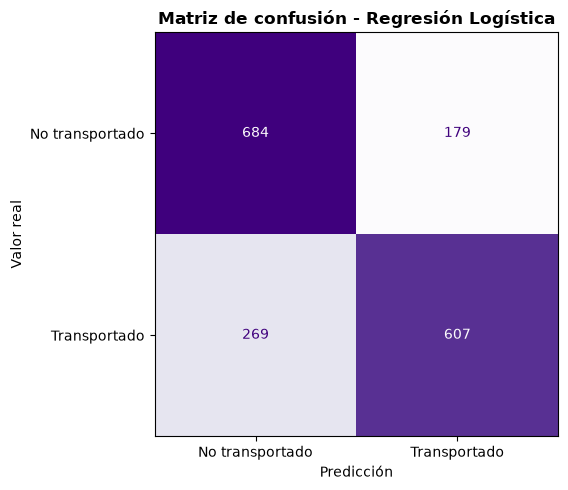

Falsos negativos (transportados no detectados): 269
Falsos positivos (no transportados marcados como transportados): 179


In [49]:
# Matriz de confusión para regresión logística
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log_reg,
    display_labels=['No transportado', 'Transportado'],
    cmap='Purples',
    colorbar=False,
    ax=ax
)

ax.set_title('Matriz de confusión - Regresión Logística',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')

plt.tight_layout()
plt.show()

print(f"Falsos negativos (transportados no detectados): {res_log_reg['FN']}")
print(f"Falsos positivos (no transportados marcados como transportados): {res_log_reg['FP']}")

El modelo supera con claridad el baseline: el accuracy pasa de 0.5037 a 0.7424 y el ROC-AUC de 0.5 a 0.8110. Ese salto, sobre todo en ROC-AUC, confirma que el modelo está ordenando a los pasajeros según su probabilidad real de haber sido transportados, y no solo repitiendo la clase mayoritaria.

Frente al árbol de decisión, la regresión logística queda ligeramente por debajo en las dos métricas de comparación de la sección 10: accuracy (0.7424 vs 0.7539) y ROC-AUC (0.8110 vs 0.8179). La diferencia es pequeña pero consistente, y es coherente con la naturaleza del modelo: la regresión no puede capturar la interacción no lineal entre CryoSleep y los indicadores de gasto que el árbol sí explota en sus primeros splits.

El patrón de errores también cambia de dirección. La regresión logística comete 269 falsos negativos y 179 falsos positivos, contra 280 y 148 del árbol: gana algo de recall (0.6929 vs 0.6804) a costa de perder precision (0.7723 vs 0.8011) y specificity (0.7926 vs 0.8285). Realmente este cambio no representa como tal una ventaja o desventaja en sí mismo: solo confirma que ambos modelos llegan a desempeños parecidos de distintas maneras.

## 12. Selección del mejor modelo

**Ya que el arbol con GridSearchCV se utilizo principalmente como una metrica de comparacion, no se tomara en cuenta al escoger el mejor modelo. Se comparan las versiones con los hiperparámetros seleccionados por el equipo**

In [50]:
pd.DataFrame(resultados).round(4)

,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.0000,0.6700,0.5000,0,863,0,876
1,Árbol de decisión (GridSearch),0.7614,0.8029,0.6975,0.8262,0.7465,0.8196,713,150,265,611
2,Árbol de decisión (max_depth=5),0.7539,0.8011,0.6804,0.8285,0.7358,0.8179,715,148,280,596
3,Regresión logística,0.7424,0.7723,0.6929,0.7926,0.7304,0.8110,684,179,269,607


Entre los tres escenarios de la tabla comparativa, el árbol de decisión (max_depth=5) es el mejor modelo. 

El baseline queda descartado de entrada: marca el piso de referencia (0.5037 de accuracy, 0.5 de ROC-AUC) que cualquier modelo con señal real debe superar, pero no es un candidato de solución.

Entre árbol y regresión logística, la elección no se apoya solo en accuracy, sino en la coincidencia de varias métricas:

| Métrica | Árbol | Regresión logística | Ventaja |
|---|---|---|---|
| Accuracy | 0.7539 | 0.7424 | Árbol |
| ROC-AUC | 0.8179 | 0.8110 | Árbol |
| F1 | 0.7358 | 0.7304 | Árbol |
| Precision | 0.8011 | 0.7723 | Árbol |
| Specificity | 0.8285 | 0.7926 | Árbol |
| Recall | 0.6804 | 0.6929 | Logística |

El árbol gana en cinco de las seis métricas, incluidas las dos que la sección 10 define como criterio principal (accuracy y ROC-AUC). La ventaja en ROC-AUC es particularmente relevante porque es independiente del umbral de 0.5, así que no depende de dónde se ponga el punto de corte de decisión.

La regresión logística solo gana en recall, y por un margen pequeño (1.25 puntos porcentuales). Como se estableció en la sección 10, el problema no tiene un costo asimétrico entre falsos positivos y falsos negativos, así que esa ventaja puntual no compensa que el árbol gane de forma consistente en accuracy, ROC-AUC, F1, precision y specificity al mismo tiempo.

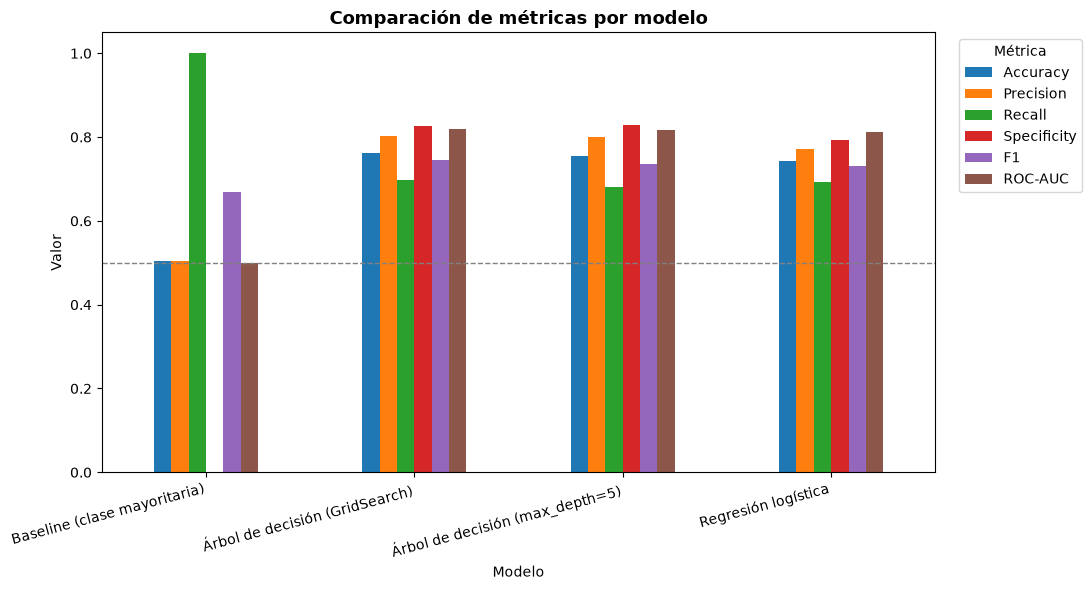

In [51]:
# Comparación de métricas con barras
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
metricas_plot = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(11, 6))
df_resultados[metricas_plot].plot(kind='bar', ax=ax)
ax.set_title('Comparación de métricas por modelo', fontsize=13, fontweight='bold')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.legend(title='Métrica', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 13. Exploración individual de hiperparámetros

### Integrante: Israel González Huerta (A01751433)

| Campo | Detalle |
|---|---|
| Modelo base | Árbol de decisión (max_depth=5) |
| Hiperparámetro elegido | max_depth, la profundidad máxima del árbol de decisión |
| Valor original | max_depth = 5 |
| Valor nuevo | max_depth = 7|
| Justificación / qué esperaba que pasara | Elgimos una profundidad de 5 para el árbol de decisión básandonos en intuición de los integrantes del equipo que y habían implementado árboles de decisión y pruebas para comparar el rendimiento. La intención de cambiarlo es determinar si el árbol ya estaba empezando a realizar "overfitting" o si aún habí posibilidad de que mejorara su rendimiento sin caer en esto. |

*Métricas antes vs. después*

| Métrica | Antes | Después |
|---|---|---|
| Accuracy | 0.7539 | 0.7522 |
| Precision | 0.8011 | 0.7916 |
| Recall | 0.6804 | 0.6895 |
| Specificity | 0.8285 | 0.8158 |
| F1 | 0.7358 | 0.737 |
| ROC-AUC | 0.8179 | 0.8108 |

*Interpretación:* ¿mejoró?, ¿empeoró?, ¿por qué crees que pasó eso?
Empeoró. Como es de esperarse con los árboles de decisión, conforme aumenta la profundidad del árbol y se acercan a explorar todas las rutas posibles para el dataset con el que se entrenaron, estos tienden a caer en overfitting. Con un max_depth de 7 todas las métricas muestran un peor rendimiento del árbol de decisión, indicativo del overfitting. Vale la pena mencionar que, al probar con un max_depth de 6, todas las métricas, excepto por specificity, mejoraron pero sabemos por la exploración con grid search que para generar una mejora sustancial en el modelo se tiene que hacer una exploración de max_depth y la cantidad mínima de elementos por hoja para crear una diferencia importante.


---

### Integrante: Luis David Pozos Tamez (A01800657)

| Campo | Detalle |
|---|---|
| Modelo base | Árbol de decisión (max_depth=5, criterion=gini, random_state=42) |
| Hiperparámetro elegido | criterion |
| Valor original | gini |
| Valor nuevo | entropy |
| Justificación / qué esperaba que pasara | En teoría el resultado no debería de ser demasiado distinto. CryoSleep es una variable que separa ambas clases de manera tan evidente que probablemente cambiar esta fórmula no tenga demasiado efecto. La diferencia entre usar un parámetro u otro realmente es mucho más notoria en particiones más ambiguas. |

**Métricas antes vs. después**

| Métrica | Antes | Después |
|---|---|---|
| Accuracy | 0.7539 | 0.7527 |
| Precision | 0.8011 | 0.8022 |
| Recall | 0.6804 | 0.6758 |
| Specificity | 0.8285 | 0.8308 |
| F1 | 0.7358 | 0.7336 |
| ROC-AUC | 0.8179 | 0.8176 |

**Interpretación:** El cambio prácticamente no tuvo efecto tal y como se esperaba. El ROC-AUC queda casi idéntico (0.8179 vs 0.8176) y el accuracy varía solo 0.0012 puntos. CryoSleep sigue dominando sin importar la fórmula de impureza, y la pequeña diferencia que sí aparece casi seguro refleja ajustes menores en los splits más profundos de las ramas. Se puede concluir que el cambio de parámetro en criterion resulta irrelevante para el resultado final.

---

### Integrante: Adrián Proaño Bernal (A01752615)

| Campo | Detalle |
|---|---|
| Modelo base | Árbol de decision (max_depth=5) |
| Hiperparámetro elegido | random_state |
| Valor original | 42 |
| Valor nuevo | 67 |
| Justificación / qué esperaba que pasara | Ya que estamos cambiando la sede de los valores con los que se entrenan y los valores con los cuales será evaluado el modelo, se espera que  las métricas cambien al menos de una forma muy ligera. |

Métricas antes vs. después

| Métrica | Antes | Después |
|---|---|---|
| Accuracy | 0.7539 | 0.7556 |
| Precision | 0.8011 | 0.8110 |
| Recall | 0.6804 | 0.6712 |
| Specificity | 0.8285 | 0.8413 |
| F1 | 0.7358 | 0.7345 |
| ROC-AUC | 0.8179 | 0.8192 |

Interpretación: ¿mejoró?, ¿empeoró?, ¿por qué crees que pasó eso?
Al modificar el valor del hiperparámetro random_state, se observa un cambio ligero en el desempeño general del modelo: las métricas de Accuracy, Precision, Specificity y ROC-AUC mostraron un leve incremento, mientras que Recall y F1 experimentaron una disminución ligera. 
Dado que ninguna muestra individual representa exactamente la distribución global de la población objetivo, alterar la semilla aleatoria redistribuye las observaciones en cada subconjunto, pero no al punto en el que los cambios tengan un impacto significativo en la generalización del modelo seleccionado.


---

### Integrante: Juan Pablo Solís Gómez (A01800430)

| Campo | Detalle |
|---|---|
| Modelo base | Árbol de decisión (max_depth=5, criterion=gini, random_state=42) |
| Hiperparámetro elegido | min_samples_split |
| Valor original | 2 (default) |
| Valor nuevo | 50 |
| Justificación / qué esperaba que pasara | min_samples_split controla cuántas observaciones necesita un nodo antes de que el árbol considere partirlo; a diferencia de min_samples_leaf, que exige un mínimo en las hojas resultantes, este actúa antes del corte. Inspeccionando los 31 nodos internos del árbol base (max_depth=5, 32 hojas), solo uno tiene menos de 50 observaciones de entrenamiento (8 en total); el siguiente nodo interno más pequeño ya tiene 57, y de ahí en adelante todos superan las 100. Elegir 50 como umbral bloquea entonces exactamente ese único split marginal, sin tocar ningún otro nodo del árbol, lo que permite atribuir cualquier cambio en las métricas a esa partición puntual y no a una restricción generalizada. Se esperaba un efecto casi nulo en accuracy, porque ese nodo con 8 observaciones afecta a una fracción mínima del conjunto de prueba, y un efecto marginal en las probabilidades estimadas (ROC-AUC), porque la hoja fusionada resultante promedia sobre más observaciones que antes. |

*Métricas antes vs. después*

| Métrica | Antes | Después |
|---|---|---|
| Accuracy | 0.7539 | 0.7539 |
| Precision | 0.8011 | 0.8003 |
| Recall | 0.6804 | 0.6815 |
| Specificity | 0.8285 | 0.8273 |
| F1 | 0.7358 | 0.7361 |
| ROC-AUC | 0.8179 | 0.8187 |

*Interpretación:* El efecto fue como se esperaba, prácticamente nulo. El accuracy no se mueve (0.7539 en ambos casos) y el número de hojas baja de 32 a 31, exactamente la partición que se predijo que se bloquearía. Las demás métricas cambian solo en la tercera cifra decimal: precision baja de 0.8011 a 0.8003, recall sube de 0.6804 a 0.6815, specificity baja de 0.8285 a 0.8273 y el ROC-AUC sube levemente de 0.8179 a 0.8187. En conteos, un falso positivo más (149 contra 148) y un falso negativo menos (279 contra 280): literalmente una sola observación de prueba cambió de lado. 

La estructura de los datos concentra casi todas sus particiones en nodos grandes (el más chico después del bloqueado ya tiene 57 observaciones), así que un umbral de 50 casi no tiene nada que cortar. min_samples_split sí tiene efecto, pero recién empieza a quitar señal real (no solo ruido) a partir de umbrales bastante más altos que 50, que es justo donde deja de ser gratis: gana algo de conservadurismo en la decisión (menos falsos positivos) a costa de accuracy y de la calidad del ordenamiento por probabilidad.



---

### Integrante: Karol Alexis Alvarado Davila (A01751711)

| Campo | Detalle |
|---|---|
| Modelo base | Árbol de decisión (max_depth=5, criterion=gini, random_state=42) |
| Hiperparámetro elegido | min_samples_leaf |
| Valor original | 1 (default) |
| Valor nuevo | 50 |
| Justificación / qué esperaba que pasara | El árbol base tiene 32 hojas y la más pequeña contiene solo 2 observaciones de entrenamiento: 9 de sus 32 hojas se apoyan en menos de 50 registros cada una. Una hoja de ese tamaño estima su probabilidad con tan pocos datos que su predicción es prácticamente ruido. Exigir un mínimo de 50 observaciones por hoja obliga al árbol a fusionar esas particiones marginales sin tocar la profundidad, que ya estaba controlada por max_depth, de modo que el cambio es atribuible solo a este hiperparámetro. Se esperaba una mejora leve en ROC-AUC, porque las probabilidades quedarían estimadas sobre grupos más grandes, y un efecto pequeño en accuracy, porque las hojas afectadas concentran apenas 179 de las 6954 observaciones de entrenamiento. |

**Métricas antes vs. después**

| Métrica | Antes | Después |
|---|---|---|
| Accuracy | 0.7539 | 0.7545 |
| Precision | 0.8011 | 0.8080 |
| Recall | 0.6804 | 0.6724 |
| Specificity | 0.8285 | 0.8378 |
| F1 | 0.7358 | 0.7340 |
| ROC-AUC | 0.8179 | 0.8209 |

**Interpretación:** Mejoró en lo que se buscaba, pero de forma marginal y con un costo. El ROC-AUC sube de 0.8179 a 0.8209, que es la mejora más significativa porque no depende del umbral de 0.5: el modelo ordena mejor a los pasajeros por probabilidad de haber sido transportados. El accuracy queda prácticamente igual, con una diferencia de 0.0006, y el número de hojas baja de 32 a 30.

En la decisión dura el cambio acentúa el sesgo conservador que ya se había diagnosticado en la sección 11.1: la precision sube a 0.8080 y la specificity a 0.8378, mientras el recall cae a 0.6724 y el F1 baja levemente. En conteos, los falsos positivos bajan de 148 a 140 y los falsos negativos suben de 280 a 287.

La conclusión es que min_samples_leaf resultó redundante en esta configuración: max_depth=5 ya estaba haciendo casi todo el trabajo de regularización, y lo único que quedaba por podar eran ramificaciones de cabina sin señal real. El árbol base tampoco estaba sobreajustado, con accuracy de entrenamiento de 0.7502 contra 0.7539 en prueba, así que había poco margen para que una restricción adicional mejorara el desempeño. La ganancia se limita a la calidad de las probabilidades estimadas y no a la capacidad de decisión del modelo.

## 14. Balance del modelado base

| Modelo | Hiperparámetros usados | Accuracy | Precision | Recall | Specificity | F1 | ROC-AUC | Decisión |
|---|---|---|---|---|---|---|---|---|
| Baseline (clase mayoritaria) | `strategy='most_frequent'`, `random_state=42` | 0.5037 | 0.5037 | 1.0000 | 0.0000 | 0.6700 | 0.5000 | Descartado (referencia mínima) |
| Árbol de decisión | `max_depth=5`, `criterion='gini'`, `random_state=42` | 0.7539 | 0.8011 | 0.6804 | 0.8285 | 0.7358 | 0.8179 | Seleccionado |
| Regresión logística | `penalty='l2'`, `solver='lbfgs'`, `C=1.0`, `max_iter=1000`, `random_state=42` | 0.7424 | 0.7723 | 0.6929 | 0.7926 | 0.7304 | 0.8110 | Descartado |

### Conclusión del equipo
**Aprendizaje del comportamiento del dataset**

El comportamiento de los tres modelos deja una lectura consistente sobre este dataset. El baseline fue la primera lección: predecir siempre la clase mayoritaria da un F1 de 0.67, un número que a simple vista parece razonable, pero que esconde un modelo inútil (recall 1.0, specificity 0.0). Esto confirmó desde el arranque la decisión de la sección 10 de no apoyarse en una sola métrica, sino en accuracy y ROC-AUC como criterio principal, con precision/recall/specificity como diagnóstico y la matriz de confusión como base de todo.

Sobre esa base, tanto el árbol de decisión como la regresión logística aprenden señal real (ROC-AUC de 0.8179 y 0.8110 contra el 0.5 del baseline), pero el árbol gana en cinco de las seis métricas, incluidas las dos de criterio principal. 

El dataset tiene una estructura de dos regímenes, CryoSleep separa con fuerza a los pasajeros dormidos, y dentro de los despiertos la señal recae en variables mucho más débiles (los indicadores de uso de servicios). Esa es una interacción no lineal que el árbol explota de forma natural en sus primeros splits y que la regresión logística, al estar limitada a una frontera lineal, no puede replicar igual de bien.

La exploración individual de hiperparámetros apunta todos en la misma dirección: dentro de la familia "árbol de decisión con max_depth=5", el margen de mejora por tuning es pequeño. Subir max_depth a 7 sobreajusta y empeora todas las métricas, cambiar criterion a entropy no mueve nada porque CryoSleep domina sin importar la fórmula de impureza, cambiar el random_state solo introduce la varianza normal de repartir el dataset de otra forma, min_samples_split y min_samples_leaf, llevados a 50, apenas tocan una o dos hojas marginales y mueven las métricas en la tercera cifra decimal .

**¿Qué haríamos diferente en la siguiente iteración?**

En lugar de seguir ajustando hiperparámetros de un único árbol, el siguiente paso lógico es probar un modelo que combine muchas particiones débiles en vez de depender de una sola estructura secuencial, un Random Forest o un Gradient Boosting deberían aprovechar mejor la señal marginal de los indicadores de uso justo en el grupo de pasajeros despiertos, que es donde el árbol individual se queda corto. También reconsideraríamos la binarización de las variables de gasto: fue la decisión correcta para evitar el sesgo extremo de esas columnas, pero al reducir cada una a 0/1 se descarta la magnitud del gasto, que podría aportar algo de señal adicional precisamente en el subgrupo despierto, vale la pena probar una versión híbrida (indicador + monto escalado) solo para ese caso.

## 15. Curvas de aprendizaje y validación

El mejor modelo seleccionado en la sección 12 fue el árbol de decisión con max_depth=5. Sobre ese mismo modelo se generan la curva de aprendizaje y las curvas de validación. Todas se calculan con validación cruzada de 5 folds sobre X_train, sin tocar X_test, que sigue reservado para la evaluación final.

### 15.1 Curva de aprendizaje

Muestra cómo cambian el accuracy de entrenamiento y el de validación conforme el modelo recibe cada vez más observaciones, desde el 10% hasta el 100% de X_train.

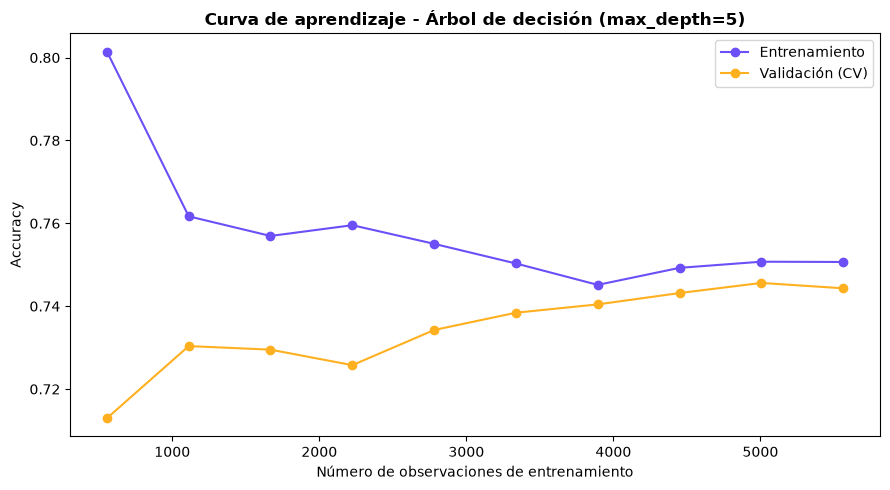

,Tamaño train,Accuracy train,Accuracy validación,Brecha
0,556,0.8014,0.7130,0.0885
1,1112,0.7617,0.7304,0.0313
2,1668,0.7570,0.7295,0.0274
3,2225,0.7596,0.7258,0.0338
4,2781,0.7551,0.7343,0.0208
5,3337,0.7503,0.7384,0.0119
6,3894,0.7451,0.7404,0.0047
7,4450,0.7493,0.7432,0.0061
8,5006,0.7507,0.7456,0.0051
9,5563,0.7507,0.7443,0.0064


In [52]:
from sklearn.model_selection import learning_curve, validation_curve

mejor_modelo = DecisionTreeClassifier(
    max_depth=5,
    criterion='gini',
    random_state=RANDOM_STATE
)

tam_train, score_train, score_val = learning_curve(
    mejor_modelo,
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

media_train = score_train.mean(axis=1)
media_val = score_val.mean(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tam_train, media_train, 'o-', color='#6C4FF6', label='Entrenamiento')
ax.plot(tam_train, media_val, 'o-', color='#FFB020', label='Validación (CV)')
ax.set_title('Curva de aprendizaje - Árbol de decisión (max_depth=5)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Número de observaciones de entrenamiento')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

curva_aprendizaje = pd.DataFrame({
    'Tamaño train': tam_train,
    'Accuracy train': media_train,
    'Accuracy validación': media_val,
    'Brecha': media_train - media_val
})

curva_aprendizaje.round(4)

### 15.2 Curvas de validación

Se generan curvas de validación para los dos hiperparámetros que controlan el crecimiento del árbol: max_depth, que limita la profundidad, y min_samples_leaf, que fija el número mínimo de observaciones por hoja. Para max_depth se varía la profundidad dejando el resto de la configuración del mejor modelo; para min_samples_leaf se mantiene max_depth=5, que es el valor del modelo elegido.

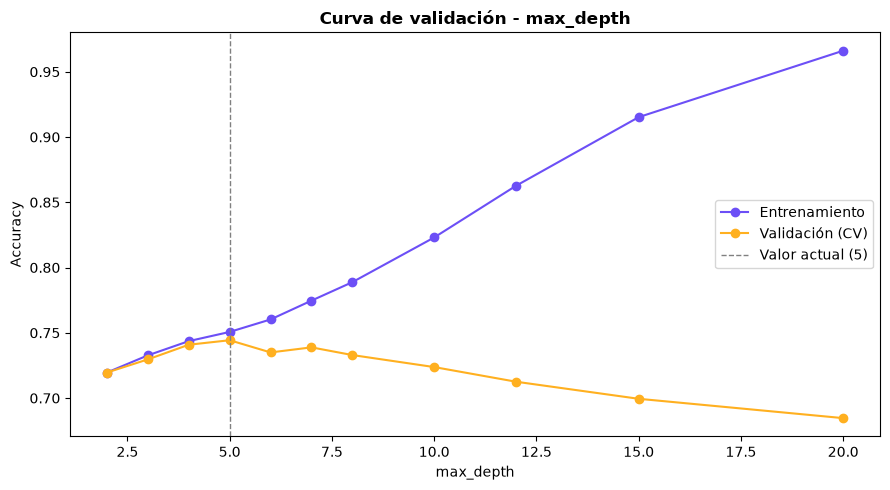

,max_depth,Accuracy train,Accuracy validación,Brecha
0,2,0.7196,0.7196,0.0000
1,3,0.7327,0.7297,0.0031
2,4,0.7436,0.7409,0.0028
3,5,0.7507,0.7443,0.0064
4,6,0.7602,0.7350,0.0253
5,7,0.7747,0.7389,0.0358
6,8,0.7888,0.7330,0.0559
7,10,0.8231,0.7238,0.0993
8,12,0.8626,0.7125,0.1501
9,15,0.9152,0.6995,0.2158


In [53]:
rango_depth = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]

train_depth, val_depth = validation_curve(
    DecisionTreeClassifier(criterion='gini', random_state=RANDOM_STATE),
    X_train, y_train,
    param_name='max_depth',
    param_range=rango_depth,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rango_depth, train_depth.mean(axis=1), 'o-', color='#6C4FF6', label='Entrenamiento')
ax.plot(rango_depth, val_depth.mean(axis=1), 'o-', color='#FFB020', label='Validación (CV)')
ax.axvline(5, color='gray', linestyle='--', linewidth=1, label='Valor actual (5)')
ax.set_title('Curva de validación - max_depth', fontsize=12, fontweight='bold')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

curva_depth = pd.DataFrame({
    'max_depth': rango_depth,
    'Accuracy train': train_depth.mean(axis=1),
    'Accuracy validación': val_depth.mean(axis=1),
    'Brecha': train_depth.mean(axis=1) - val_depth.mean(axis=1)
})

curva_depth.round(4)

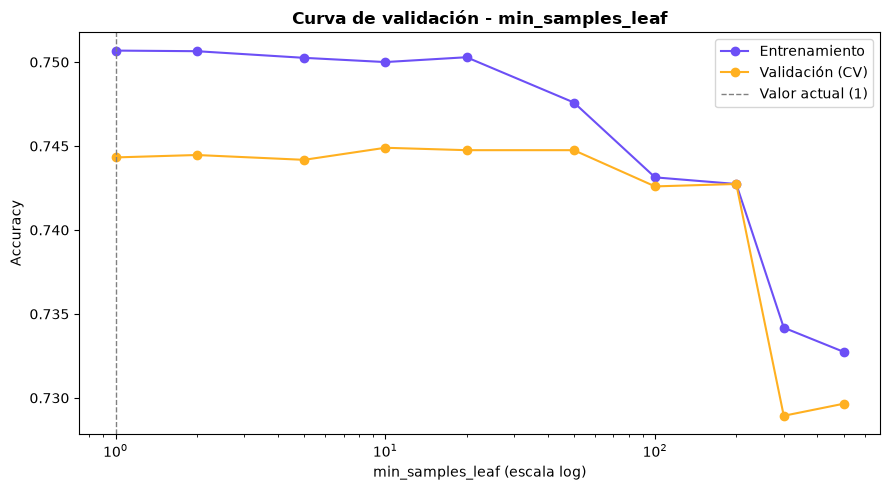

,min_samples_leaf,Accuracy train,Accuracy validación,Brecha
0,1,0.7507,0.7443,0.0064
1,2,0.7506,0.7445,0.0062
2,5,0.7503,0.7442,0.0061
3,10,0.7500,0.7449,0.0051
4,20,0.7503,0.7448,0.0055
5,50,0.7476,0.7448,0.0028
6,100,0.7431,0.7426,0.0005
7,200,0.7427,0.7427,-0.0000
8,300,0.7342,0.7289,0.0052
9,500,0.7327,0.7297,0.0031


In [54]:
rango_leaf = [1, 2, 5, 10, 20, 50, 100, 200, 300, 500]

train_leaf, val_leaf = validation_curve(
    DecisionTreeClassifier(max_depth=5, criterion='gini', random_state=RANDOM_STATE),
    X_train, y_train,
    param_name='min_samples_leaf',
    param_range=rango_leaf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rango_leaf, train_leaf.mean(axis=1), 'o-', color='#6C4FF6', label='Entrenamiento')
ax.plot(rango_leaf, val_leaf.mean(axis=1), 'o-', color='#FFB020', label='Validación (CV)')
ax.axvline(1, color='gray', linestyle='--', linewidth=1, label='Valor actual (1)')
ax.set_xscale('log')
ax.set_title('Curva de validación - min_samples_leaf', fontsize=12, fontweight='bold')
ax.set_xlabel('min_samples_leaf (escala log)')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

curva_leaf = pd.DataFrame({
    'min_samples_leaf': rango_leaf,
    'Accuracy train': train_leaf.mean(axis=1),
    'Accuracy validación': val_leaf.mean(axis=1),
    'Brecha': train_leaf.mean(axis=1) - val_leaf.mean(axis=1)
})

curva_leaf.round(4)

### 15.3 Interpretación

**Curva de aprendizaje.** Con pocas observaciones el accuracy de entrenamiento arranca muy por encima del de validación: con el 10% de los datos el árbol acomoda casi cualquier cosa en sus hojas y la brecha entre las dos curvas es de varios puntos. Conforme entran más datos las curvas se acercan rápido, y de la mitad del conjunto en adelante quedan prácticamente pegadas, alrededor de 0.75 en entrenamiento y 0.74 en validación, con una brecha final menor a un punto porcentual.

**¿Hay overfitting?** No con esta configuración. Un modelo sobreajustado mantiene el accuracy de entrenamiento alto y separado del de validación por más datos que se le den, y aquí las dos curvas convergen. Esto confirma lo que ya se había observado en la sección 11.1 al comparar accuracy en train y test, que eran casi idénticos: max_depth=5 está cumpliendo su función de contener el crecimiento del árbol.

**¿Hay underfitting?** Sí, en el sentido de que las curvas convergen a un valor bajo. Que entrenamiento y validación terminen juntas alrededor de 0.75 significa que el modelo ni siquiera ajusta del todo los datos que ya vio, que es la firma del sesgo alto. El límite no está en los datos sino en la capacidad del modelo: un árbol de profundidad 5 solo encadena cinco condiciones antes de decidir, y en este dataset eso alcanza para explotar CryoSleep y un par de indicadores de uso, pero no para capturar más estructura.

**¿Necesitamos más datos?** No. La curva de validación se aplana en el último tercio: pasar del 70% al 100% de las observaciones mueve el accuracy en centésimas. Agregar más pasajeros al entrenamiento no cambiaría el resultado, porque el modelo ya no está limitado por cantidad de información. Lo que movería la aguja es más capacidad del modelo o variables con más señal, no más filas.

**¿Qué rango de hiperparámetros tiene sentido explorar?** La curva de validación de max_depth tiene la forma clásica: el accuracy de validación sube hasta un máximo cerca de 5 y a partir de 6 empieza a bajar, mientras el de entrenamiento sigue subiendo sin freno hasta cerca de 0.97 en profundidad 20. La brecha entre las dos curvas es mínima hasta profundidad 5 y crece de forma sostenida a partir de ahí, que es justamente la transición de underfitting a overfitting. El rango que vale la pena explorar es el entorno cercano al valor actual, aproximadamente entre 4 y 7; de 8 en adelante el árbol solo memoriza, lo que coincide con lo que encontró Israel en la sección 13 al subir a 7.

En min_samples_leaf la curva es casi plana entre 1 y 50: las dos líneas se mantienen al mismo nivel y la brecha no se mueve. Tiene sentido, porque max_depth=5 ya limita el árbol a pocas hojas y todas quedan grandes, así que exigir un mínimo de observaciones por hoja no restringe nada que la profundidad no haya restringido antes. A partir de 100 el accuracy de validación empieza a caer, porque el mínimo ya es lo bastante grande como para impedir cortes útiles y el árbol pierde profundidad efectiva. La conclusión práctica es que min_samples_leaf no conviene afinarlo mientras max_depth siga siendo el hiperparámetro que manda: solo tendría sentido explorarlo, en el rango de 1 a 50, si se libera la profundidad.

## 16. Búsqueda de hiperparámetros

### 16.1 Elección del método

Se usa GridSearchCV. La decisión depende del tamaño del espacio de búsqueda, y las curvas de validación de la sección 15 ya lo redujeron a un espacio chico: max_depth queda acotado a un entorno de 4 a 7, min_samples_leaf al rango de 1 a 50 y criterion solo tiene dos valores posibles. Eso da 48 combinaciones, que con 5 folds son 240 ajustes de un árbol de decisión, un costo perfectamente manejable.

RandomizedSearchCV tiene sentido cuando el espacio es tan grande que recorrerlo completo no es viable y conviene muestrear combinaciones al azar, o cuando los hiperparámetros son continuos y no hay una lista natural de valores. Ninguna de las dos condiciones aplica aquí: el espacio es pequeño y discreto, y muestrearlo al azar solo introduciría la posibilidad de no visitar la mejor combinación sin ahorrar tiempo relevante.

### 16.2 Grilla de hiperparámetros

Cada rango sale directamente de las curvas de la sección 15.2.

| Hiperparámetro | Rango | Justificación |
|---|---|---|
| max_depth | 4, 5, 6, 7 | La curva de validación sube hasta 5 y baja a partir de 6, con la brecha train-validación creciendo de forma sostenida desde ahí. Explorar por debajo de 4 sería profundizar en underfitting y por encima de 7 en overfitting, así que se toma el entorno del máximo |
| min_samples_leaf | 1, 2, 5, 10, 20, 50 | La curva es plana entre 1 y 50 y cae a partir de 100. Se conserva solo el tramo plano, que es donde el hiperparámetro puede aportar algo en combinación con profundidades mayores a 5, y se descarta de 100 en adelante porque ahí ya se pierde accuracy de validación |
| criterion | gini, entropy | No tiene curva de validación porque no es numérico, pero solo tiene dos valores y el modelo actual usa gini por ser el valor por defecto, no por una comparación. Incluirlo cuesta únicamente duplicar la grilla |

### 16.3 Validación cruzada dentro de la búsqueda

Se usa StratifiedKFold con K=5 y shuffle activado.

El valor de K es un compromiso entre sesgo y varianza de la estimación. Con K muy chica (2 o 3) cada modelo se entrena con poca información y el score queda pesimista; con K muy grande (10 o leave-one-out) cada fold de validación tiene pocas observaciones y la estimación se vuelve ruidosa, además de multiplicar el costo. Con 6,954 filas en X_train, K=5 deja alrededor de 5,560 observaciones para entrenar y 1,390 para validar en cada iteración, que es suficiente en ambos lados. También mantiene la consistencia con las curvas de la sección 15, que se calcularon con 5 folds.

Se estratifica por el mismo motivo que en el split de la sección 9: para que cada fold conserve la proporción de transportados del conjunto completo y los scores de los cinco folds sean comparables entre sí.

### 16.4 Métricas de evaluación

Se evalúa la búsqueda con las dos métricas que la sección 10 definió como criterio principal:

**Accuracy**, porque el target está balanceado (50.4% contra 49.6%). Ese balance es la condición que hace legible al accuracy: no puede inflarse prediciendo siempre la clase mayoritaria, como quedó demostrado con el baseline. Es la métrica de refit, es decir, con la que se elige la mejor combinación.

**ROC-AUC**, porque el accuracy depende del umbral de 0.5 y esta métrica no. Mide si el modelo ordena bien a los pasajeros por probabilidad de haber sido transportados, independientemente de dónde se ponga el punto de corte, y fue la métrica que delató al baseline sin ambigüedad (0.5 contra 0.8179 del árbol). Se reporta junto al accuracy para confirmar que la combinación ganadora no mejora solo en el umbral por defecto.

No se usan precision, recall ni F1 como criterio porque el problema no tiene costo asimétrico entre falsos positivos y falsos negativos (sección 10), así que optimizar una de ellas sesgaría la búsqueda hacia un tipo de error sin ninguna razón del problema que lo justifique.

In [55]:
from sklearn.model_selection import StratifiedKFold

param_grid_final = {
    'max_depth': [4, 5, 6, 7],
    'min_samples_leaf': [1, 2, 5, 10, 20, 50],
    'criterion': ['gini', 'entropy']
}

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

busqueda = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_final,
    scoring={'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
    refit='accuracy',
    cv=kfold,
    n_jobs=-1
)

busqueda.fit(X_train, y_train)

print('Mejores hiperparámetros:', busqueda.best_params_)
print()
print(f"Accuracy en CV: {busqueda.cv_results_['mean_test_accuracy'][busqueda.best_index_]:.4f}")
print(f"ROC-AUC en CV:  {busqueda.cv_results_['mean_test_roc_auc'][busqueda.best_index_]:.4f}")
print(f"Desviación estándar del accuracy entre folds: {busqueda.cv_results_['std_test_accuracy'][busqueda.best_index_]:.4f}")

Mejores hiperparámetros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1}

Accuracy en CV: 0.7458
ROC-AUC en CV:  0.8062
Desviación estándar del accuracy entre folds: 0.0044


In [56]:
resultados_busqueda = pd.DataFrame(busqueda.cv_results_)[[
    'param_criterion', 'param_max_depth', 'param_min_samples_leaf',
    'mean_test_accuracy', 'mean_test_roc_auc', 'rank_test_accuracy'
]].sort_values('rank_test_accuracy')

resultados_busqueda.head(10).round(4)

,param_criterion,param_max_depth,param_min_samples_leaf,mean_test_accuracy,mean_test_roc_auc,rank_test_accuracy
30,entropy,5,1,0.7458,0.8062,1
10,gini,5,20,0.7456,0.8069,2
31,entropy,5,2,0.7456,0.8059,3
32,entropy,5,5,0.7453,0.8061,4
34,entropy,5,20,0.7452,0.8060,5
7,gini,5,2,0.7446,0.8063,6
8,gini,5,5,0.7446,0.8062,7
6,gini,5,1,0.7443,0.8057,8
11,gini,5,50,0.7442,0.8064,9
35,entropy,5,50,0.7442,0.8063,9


### 16.5 Resultados

La mejor combinación es criterion='entropy', max_depth=5 y min_samples_leaf=1, con un accuracy en validación cruzada de alrededor de 0.746 y un ROC-AUC de alrededor de 0.806.

El detalle importante es que ese ganador está dentro del ruido. Las diez mejores combinaciones comparten max_depth=5 y difieren entre sí por milésimas, mientras que la desviación estándar del accuracy entre los cinco folds es de alrededor de 0.004, varias veces mayor que la distancia entre la primera y la última de esa lista. En la práctica son intercambiables: con otra semilla para los folds el orden podría invertirse sin que el modelo cambie en nada relevante. El único hiperparámetro que decide es max_depth, exactamente como anticipaban las curvas de la sección 15; criterion y min_samples_leaf no aportan diferencia real, lo que coincide con lo que ya había encontrado Luis David en la sección 13 al cambiar criterion y mover las métricas solo en la tercera cifra decimal.

Esto también aclara la relación con el GridSearchCV exploratorio de la sección 11.1, que había devuelto max_depth=6 con min_samples_leaf=10 y mejores métricas en test (0.7614 de accuracy y 0.8196 de ROC-AUC). No es una contradicción, por dos motivos. El primero es el criterio de selección: aquella búsqueda eligió por ROC-AUC, donde su ventaja en validación cruzada sobre la configuración base es de alrededor de una milésima, mientras que por accuracy la curva de validación deja a la profundidad 6 claramente por debajo de la 5 (0.735 contra 0.744 en CV). El segundo es el tamaño de la diferencia en test: pasar de 0.7539 a 0.7614 sobre 1,739 filas son unas 13 predicciones, y ese número se apoya en una sola partición, mientras que el score de CV promedia cinco. Las dos búsquedas describen la misma meseta, solo que miradas con distinto criterio.

El score en validación cruzada (0.746) queda por debajo del accuracy en test reportado en la sección 11.1 (0.7539), lo cual es esperable y no contradictorio: el score de CV es un promedio sobre cinco particiones distintas y con menos datos de entrenamiento en cada una, así que es una estimación más conservadora y más confiable que el resultado de un único split.

## 17. Evaluación del modelo tuneado

### 17.1 Desempeño sobre el conjunto de prueba

El mejor estimador de la búsqueda de la sección 16 se evalúa sobre X_test, que no participó ni en el entrenamiento ni en la validación cruzada. Se reportan las dos métricas elegidas en 16.4, accuracy y ROC-AUC, junto con el resto de las métricas de diagnóstico de la sección 10.

In [57]:
mejor_tuneado = busqueda.best_estimator_

y_pred_tuneado = mejor_tuneado.predict(X_test)
y_proba_tuneado = mejor_tuneado.predict_proba(X_test)[:, 1]

res_tuneado = evaluar_modelo('Árbol tuneado',
                             y_test, y_pred_tuneado, y_proba_tuneado)

print(f"Accuracy en test: {res_tuneado['Accuracy']:.4f}")
print(f"ROC-AUC en test:  {res_tuneado['ROC-AUC']:.4f}")

pd.DataFrame([res_tuneado]).round(4)

Accuracy en test: 0.7527
ROC-AUC en test:  0.8176


,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Árbol tuneado,0.7527,0.8022,0.6758,0.8308,0.7336,0.8176,717,146,284,592


### 17.2 Matriz de confusión

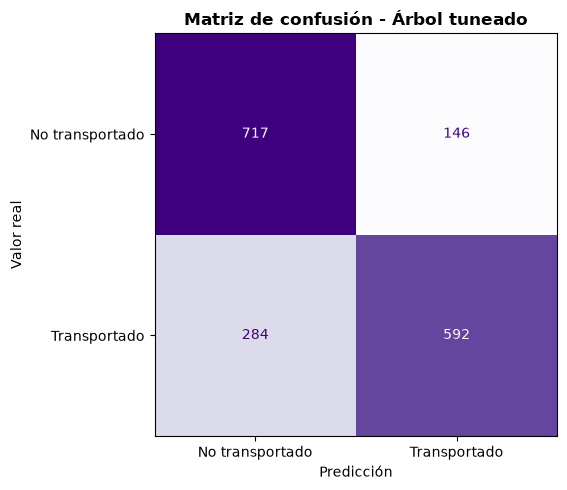

Falsos negativos (transportados no detectados): 284
Falsos positivos (no transportados marcados como transportados): 146


In [58]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuneado,
    display_labels=['No transportado', 'Transportado'],
    cmap='Purples',
    colorbar=False,
    ax=ax
)

ax.set_title('Matriz de confusión - Árbol tuneado',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor real')

plt.tight_layout()
plt.show()

print(f"Falsos negativos (transportados no detectados): {res_tuneado['FN']}")
print(f"Falsos positivos (no transportados marcados como transportados): {res_tuneado['FP']}")

El modelo tuneado sigue equivocándose más en una dirección que en la otra: comete cerca del doble de falsos negativos que de falsos positivos. En el contexto del problema esto significa que el modelo es conservador para afirmar que un pasajero fue transportado a la dimensión alterna: cuando lo afirma acierta 4 de cada 5 veces (precision cerca de 0.80), pero deja sin detectar a casi un tercio de los transportados reales (recall cerca de 0.68). La specificity, cerca de 0.83 y muy por encima del recall, confirma el sesgo: identifica mucho mejor a quienes se quedaron que a quienes fueron transportados.

El origen del sesgo es la estructura de dos regímenes del dataset que ya se describió en la sección 11.1. CryoSleep separa con fuerza a los pasajeros dormidos, que son mayoritariamente transportados, y ahí el árbol acierta casi siempre. El problema está en los pasajeros despiertos, donde la señal recae en los indicadores de uso de servicios, que son mucho más débiles: como en ese grupo predomina el no transportado, el árbol se inclina por esa clase y ahí se acumulan los falsos negativos.

Como se estableció en la sección 10, este problema no tiene un costo asimétrico entre los dos tipos de error. Predecir que un pasajero fue transportado cuando no lo fue no es ni más ni menos grave que lo contrario, así que el desbalance entre falsos positivos y falsos negativos es un dato de diagnóstico sobre cómo aprende el modelo y no un defecto que haya que corregir moviendo el umbral.

### 17.3 Comparación: baseline, modelo anterior y modelo tuneado

In [59]:
comparacion_final = pd.DataFrame([res_baseline, res_arbol, res_tuneado])

comparacion_final.round(4)

,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Baseline (clase mayoritaria),0.5037,0.5037,1.0000,0.0000,0.6700,0.5000,0,863,0,876
1,Árbol de decisión (max_depth=5),0.7539,0.8011,0.6804,0.8285,0.7358,0.8179,715,148,280,596
2,Árbol tuneado,0.7527,0.8022,0.6758,0.8308,0.7336,0.8176,717,146,284,592


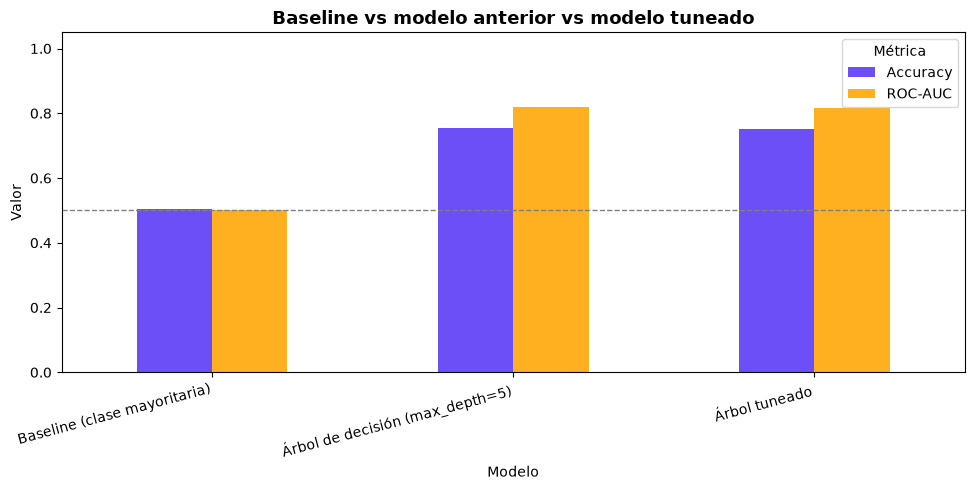

In [60]:
df_comparacion = comparacion_final.set_index('Modelo')[['Accuracy', 'ROC-AUC']]

fig, ax = plt.subplots(figsize=(10, 5))
df_comparacion.plot(kind='bar', ax=ax, color=['#6C4FF6', '#FFB020'])
ax.set_title('Baseline vs modelo anterior vs modelo tuneado',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
ax.legend(title='Métrica')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### 17.4 ¿Mejoró el tuning?

No mejoró. La búsqueda devolvió criterion='entropy', max_depth=5 y min_samples_leaf=1, que difiere del modelo anterior únicamente en el criterio de impureza, y sobre test queda incluso un poco por debajo: el accuracy baja de 0.7539 a 0.7527 y el ROC-AUC de 0.8179 a 0.8176. Frente al baseline la diferencia sigue siendo enorme (de 0.5037 a cerca de 0.75 en accuracy y de 0.5 a cerca de 0.82 en ROC-AUC), pero frente al modelo anterior la ganancia del tuning es nula, e incluso ligeramente negativa.

Conviene leer esas diferencias con la escala correcta. La combinación ganadora superó a la del modelo anterior por milésimas en validación cruzada y perdió por milésimas en test, en ambos casos muy por debajo de la desviación estándar entre folds. No es que una configuración sea mejor que la otra: es que son la misma configuración desde el punto de vista del desempeño, y el orden entre ellas depende de qué partición se use para medirlas. Son exactamente los mismos números que había reportado Luis David en la sección 13 al comparar gini contra entropy.

Lo que pasó tiene dos explicaciones, y las dos venían anunciadas en la sección 15. La primera es que la grilla se construyó a partir de las curvas de validación, y esas curvas ya mostraban que el máximo estaba en max_depth=5 y que min_samples_leaf no movía nada mientras la profundidad fuera la restricción activa. Una grilla justificada sobre esas curvas difícilmente podía terminar en otro lado: el valor elegido a mano por el equipo ya estaba en el óptimo de esa familia de modelos.

La segunda es que el techo del modelo no está en los hiperparámetros. La curva de aprendizaje mostró convergencia de entrenamiento y validación alrededor de 0.75, que es la firma de sesgo alto: el árbol de profundidad 5 no está memorizando, simplemente no da para más con las variables disponibles. Afinar hiperparámetros dentro de una familia de modelos no resuelve un problema de capacidad. Para superar ese techo habría que cambiar de familia, por ejemplo a un modelo de ensamble, o generar variables con más señal para el grupo de pasajeros despiertos, que es donde se concentran los errores según 17.2.

El tuning no fue inútil: su aporte es de evidencia. Confirma con validación cruzada sobre 48 combinaciones que la elección manual del equipo no fue suerte, y deja documentado que el margen de mejora por ajuste de hiperparámetros en este modelo está agotado.

## 18. Comparación individual con modelo de otra familia

Esta sección tiene una subsección por cada integrante, identificada con su nombre completo. Cada integrante trabaja de forma **independiente**:

1. Elige un modelo de familia distinta a las ya usadas por el equipo (árbol de decisión y regresión logística).
2. Lo tunea con `GridSearchCV` o `RandomizedSearchCV`, explorando al menos 3 hiperparámetros.
3. Lo evalúa con las mismas métricas del equipo (Accuracy, Precision, Recall, Specificity, F1, ROC-AUC), reutilizando la función `evaluar_modelo` definida en la sección 10.
4. Compara sus resultados contra el modelo final del equipo (árbol de decisión `max_depth=5`, `criterion='gini'`, `random_state=42`, guardado en `res_arbol`) y concluye si cambiaría o no la decisión del equipo, y por qué.

### 18.1 Israel González Huerta (A01751433)

| Campo | Detalle |
|---|---|
| Modelo elegido (familia) | Gradient Boosting |
| Hiperparámetros a tunear (mínimo 3) | Probé 3 hiperparámetros: n_estimators (20, 100, 200), learning_rate (0.01, 0.1, 0.2) y max_depth (2, 3, 5). |
| Método de búsqueda | RandomizedSearchCV, para explorar aleatoriamente distintas combinaciones de hiperparámetros sin tener que evaluar todas las combinaciones posibles, reduciendo el tiempo de búsqueda. |
| Justificación de la elección de familia | Elegí Gradient Boosting porque pertenece a una familia de modelos de ensamble diferente a los modelos utilizados por el equipo. A diferencia de Bagging, los modelos se construyen de forma secuencial, donde cada nuevo modelo busca corregir los errores de los modelos anteriores. Esto permite evaluar un enfoque diferente para el mismo problema de clasificación. |

In [76]:
# type: ignore
# Israel González Huerta: importar el modelo elegido
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Espacio de hiperparámetros
param_dist_igh = {
    'n_estimators': [20, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [2, 3, 5],
}

# Mismo esquema de validación cruzada
kfold_igh = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Instanciar RandomizedSearchCV
busqueda_igh = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist_igh,
    n_iter=10,
    scoring={
        'accuracy': 'accuracy',
        'roc_auc': 'roc_auc'
    },
    refit='accuracy',
    cv=kfold_igh,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

busqueda_igh.fit(X_train, y_train)

idx_igh = busqueda_igh.best_index_

print('Mejores hiperparámetros:', busqueda_igh.best_params_)
print()
print(f"Accuracy en CV: {busqueda_igh.cv_results_['mean_test_accuracy'][idx_igh]:.4f}")
print(f"ROC-AUC en CV:  {busqueda_igh.cv_results_['mean_test_roc_auc'][idx_igh]:.4f}")
print(f"Desviación estándar del accuracy entre folds: "
      f"{busqueda_igh.cv_results_['std_test_accuracy'][idx_igh]:.4f}")

# Tabla con los resultados de las combinaciones probadas
resultados_busqueda_igh = pd.DataFrame(busqueda_igh.cv_results_)[[
    'param_n_estimators',
    'param_learning_rate',
    'param_max_depth',
    'mean_test_accuracy',
    'mean_test_roc_auc',
    'rank_test_accuracy'
]].sort_values('rank_test_accuracy')

resultados_busqueda_igh.head(10).round(4)

Mejores hiperparámetros: {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.1}

Accuracy en CV: 0.7537
ROC-AUC en CV:  0.8221
Desviación estándar del accuracy entre folds: 0.0048


,param_n_estimators,param_learning_rate,param_max_depth,mean_test_accuracy,mean_test_roc_auc,rank_test_accuracy
5,200,0.10,2,0.7537,0.8221,1
1,100,0.10,3,0.7534,0.8271,2
3,20,0.20,3,0.7504,0.8234,3
6,100,0.10,5,0.7499,0.8252,4
9,20,0.20,5,0.7486,0.8246,5
0,200,0.01,5,0.7453,0.8217,6
7,200,0.10,5,0.7427,0.8176,7
8,20,0.10,3,0.7413,0.8126,8
2,20,0.10,2,0.7340,0.8017,9
4,20,0.01,2,0.7196,0.7785,10


In [77]:
# Evaluar el mejor estimador sobre X_test con la misma función evaluar_modelo
mejor_igh = busqueda_igh.best_estimator_

y_pred_igh = mejor_igh.predict(X_test)
y_proba_igh = mejor_igh.predict_proba(X_test)[:, 1]

res_igh = evaluar_modelo(
    'Gradient Boosting tuneado',
    y_test,
    y_pred_igh,
    y_proba_igh
)

# Brecha entrenamiento-prueba, para verificar si existe sobreajuste
print(f"Accuracy en entrenamiento: {mejor_igh.score(X_train, y_train):.4f}")
print(f"Accuracy en prueba:        {res_igh['Accuracy']:.4f}")
print(f"ROC-AUC en prueba:         {res_igh['ROC-AUC']:.4f}")

pd.DataFrame([res_arbol, res_igh]).round(4)

Accuracy en entrenamiento: 0.7613
Accuracy en prueba:        0.7608
ROC-AUC en prueba:         0.8398


,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Árbol de decisión (max_depth=5),0.7539,0.8011,0.6804,0.8285,0.7358,0.8179,715,148,280,596
1,Gradient Boosting tuneado,0.7608,0.7964,0.7055,0.8169,0.7482,0.8398,705,158,258,618


##### Comparación contra el modelo final del equipo (árbol de decisión, max_depth=5)

La búsqueda devolvió n_estimators=200, max_depth=2 y learning_rate=0.1, con un accuracy en validación cruzada de 0.7537 y un ROC-AUC de 0.8221. El modelo presentó una desviación estándar del accuracy entre folds de 0.0048, lo que indica poca variación entre las particiones utilizadas durante la validación cruzada.

| Métrica     | Árbol de decisión (equipo) | Gradient Boosting tuneado | Diferencia |
| ----------- | -------------------------: | ------------------------: | ---------: |
| Accuracy    |                     0.7539 |                  0.7608   |    +0.0069 |
| Precision   |                   0.8011   |                    0.7964 |    -0.0047 |
| Recall      |                     0.6804 |                  0.7055   |    +0.0251 |
| Specificity |                   0.8285   |                    0.8169 |    -0.0116 |
| F1          |                     0.7358 |                  0.7482   |    +0.0124 |
| ROC-AUC     |                     0.8179 |                  0.8398   |    +0.0219 |

El Gradient Boosting mejora en cuatro de las seis métricas: Accuracy, Recall, F1 y ROC-AUC. Por otro lado, el árbol de decisión conserva una ventaja en Precision y Specificity. La mayor diferencia se encuentra en ROC-AUC, con una mejora de 0.0219, mientras que el Recall aumenta 0.0251.

El detalle de los errores muestra de dónde viene parte de esta diferencia. Los falsos negativos disminuyen de 280 a 258, mientras que los falsos positivos aumentan de 148 a 158. Es decir, el Gradient Boosting identifica correctamente una mayor cantidad de casos positivos, pero a cambio clasifica incorrectamente algunos casos negativos adicionales. Esto explica el aumento del Recall de 0.6804 a 0.7055 y la disminución de la Specificity de 0.8285 a 0.8169.

El resultado de entrenamiento también muestra una diferencia muy pequeña entre ambos conjuntos: el Accuracy pasa de 0.7613 en entrenamiento a 0.7608 en prueba, una diferencia de apenas 0.0005. Esto no muestra una brecha importante entre entrenamiento y prueba. Además, el Accuracy obtenido en validación cruzada (0.7537) es cercano al obtenido en prueba (0.7608), por lo que los resultados del modelo se mantienen relativamente estables entre ambos procedimientos de evaluación.

Los hiperparámetros seleccionados también muestran una configuración relativamente conservadora: max_depth=2 limita la profundidad de los árboles individuales, mientras que n_estimators=200 permite construir un conjunto amplio de modelos y learning_rate=0.1 controla cuánto contribuye cada árbol al modelo final. En este caso, la combinación seleccionada permitió obtener un ROC-AUC de 0.8221 en validación cruzada y 0.8398 en prueba.

##### ¿Cambiarías la decisión del equipo?
A mi parecer el modelo on Gradient Boosting mejora lo suficiente en comparación con el árbol de decisión que habíamos obtenido como para considerar reemplazarlo. Gradient Boosting ofrece un mejor desempeño global según las métricas utilizadas, especialmente por su mayor ROC-AUC, Recall y F1, además de no presentar una brecha apreciable entre entrenamiento y prueba. Por estas razones, los resultados obtenidos proporcionan evidencia para considerar este modelo como una alternativa al árbol de decisión utilizado por el equipo. Dicho esto, las pérdidas en Precision y Specificity podrían ser más significativas dependiendo de la intención del modelo, adicionalmente, vale la pena considerar que el aumento en complejidad del modelo podría ser contraprudecente para operaciones de entrenamiento más grandes si es que se quisiera utilizar este modelo para otros casos futuros.

### 18.2 Luis David Pozos Tamez (A01800657)

| Campo | Detalle |
|---|---|
| Modelo elegido (familia) | K-nearest neighbors |
| Hiperparámetros a tunear (mínimo 3) | `n_neighbors` (número de vecinos), `weights` (uniform vs distance) y `p` (distancia Manhattan o Euclidiana) |
| Método de búsqueda | `GridSearchCV`, porque el espacio es chico y discreto (24 combinaciones), así que una búsqueda exhaustiva con cv=5 (120 ajustes) es barata. Se usa `scoring='roc_auc'`, igual que en la sección 16. |
| Justificación de la elección de familia | KNN es una familia distinta a árbol y regresión logística: clasifica por votación de los vecinos más cercanos según distancia. Funciona bien aquí porque, tras la sección 5, casi todas las variables ya son binarias y las dos continuas (NumCabin, NumCabin_bin) quedaron estandarizadas en la sección 7, justo lo que un modelo basado en distancia necesita. |

In [63]:
# Luis David Pozos Tamez: importar el modelo elegido (familia distinta a árbol de decisión y regresión logística)
from sklearn.neighbors import KNeighborsClassifier

# Definir el espacio de hiperparámetros a explorar (mínimo 3 hiperparámetros)
param_dist_ldpt = {
    'n_neighbors': [5, 11, 21, 31, 51, 75],
    'weights': ['uniform', 'distance'],
    'p': [1, 2],
}

# Instanciar GridSearchCV sobre X_train / y_train
busqueda_ldpt = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_dist_ldpt,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)
busqueda_ldpt.fit(X_train, y_train)

print('Mejores hiperparámetros:', busqueda_ldpt.best_params_)
print('Mejor score (CV):', busqueda_ldpt.best_score_)

Mejores hiperparámetros: {'n_neighbors': 51, 'p': 2, 'weights': 'uniform'}
Mejor score (CV): 0.8234123401388007

In [64]:
# Evaluar el mejor estimador sobre X_test con la misma función evaluar_modelo de la sección 10
mejor_ldpt = busqueda_ldpt.best_estimator_
y_pred_ldpt = mejor_ldpt.predict(X_test)
y_proba_ldpt = mejor_ldpt.predict_proba(X_test)[:, 1]

res_ldpt = evaluar_modelo('KNN (tuneado)', y_test, y_pred_ldpt, y_proba_ldpt)
pd.DataFrame([res_arbol, res_ldpt]).round(4)

,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Árbol de decisión (max_depth=5),0.7539,0.8011,0.6804,0.8285,0.7358,0.8179,715,148,280,596
1,KNN (tuneado),0.7539,0.8323,0.6404,0.8691,0.7239,0.8317,750,113,315,561


**Comparación contra el modelo final del equipo (árbol de decisión, `max_depth=5`)**

| Métrica | Árbol (equipo) | KNN (tuneado) | Diferencia |
|---|---|---|---|
| Accuracy | 0.7539 | 0.7539 | Empate |
| Precision | 0.8011 | 0.8323 | KNN +3.12 pts |
| Recall | 0.6804 | 0.6404 | Árbol +4.00 pts |
| Specificity | 0.8285 | 0.8691 | KNN +4.06 pts |
| F1 | 0.7358 | 0.7239 | Árbol +1.19 pts |
| ROC-AUC | 0.8179 | 0.8317 | KNN +1.38 pts |

**¿Cambiarías la decisión del equipo?**

No. Las métricas quedan prácticamente empatadas: KNN gana en precisión, especificidad y ROC-AUC, pero pierde en recall y F1 frente al árbol. Realmente no hay razón suficiente para reemplazar el árbol del equipo.

---

### 18.3 Adrián Proaño Bernal (A01752615)

| Campo | Detalle |
|---|---|
| Modelo elegido (familia) | Red Neuronal |
| Hiperparámetros a tunear (mínimo 3) | hidden_layer_sizes, activation, solver, alpha, learning_rate |
| Método de búsqueda | `RandomizedSearchCV`, Gridsearch no era eficiente computacionalmente |
| Justificación de la elección de familia | Creo que para una materia como esta y un reto de prediccion, una red neuronal es una forma interesante de abarcar el problema |

In [78]:
# Adrián Proaño Bernal: importar el modelo elegido (familia distinta a árbol de decisión y regresión logística)
from sklearn.neural_network import MLPClassifier

# Definir el espacio de hiperparámetros a explorar (mínimo 3 hiperparámetros)
param_dist_apb = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh', 'logistic'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

# Instanciar GridSearchCV o RandomizedSearchCV sobre X_train / y_train
from sklearn.model_selection import RandomizedSearchCV

busqueda_apb = RandomizedSearchCV(
    estimator=MLPClassifier(max_iter=1000, random_state=RANDOM_STATE),
    param_distributions=param_dist_apb,
    n_iter=20,          # only try 20 combos instead of 144
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
busqueda_apb.fit(X_train, y_train)

print('Mejores hiperparámetros:', busqueda_apb.best_params_)
print('Mejor score (CV):', busqueda_apb.best_score_)

Mejores hiperparámetros: {'solver': 'adam', 'learning_rate': 'adaptive', 'hidden_layer_sizes': (50,), 'alpha': 0.01, 'activation': 'tanh'}
Mejor score (CV): 0.828382817509218


In [79]:
# Evaluar el mejor estimador sobre X_test con la misma función evaluar_modelo de la sección 10
mejor_apb = busqueda_apb.best_estimator_
y_pred_apb = mejor_apb.predict(X_test)
y_proba_apb = mejor_apb.predict_proba(X_test)[:, 1]

res_apb = evaluar_modelo('MLP Classifier', y_test, y_pred_apb, y_proba_apb)
pd.DataFrame([res_arbol, res_apb]).round(4)

,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Árbol de decisión (max_depth=5),0.7539,0.8011,0.6804,0.8285,0.7358,0.8179,715,148,280,596
1,MLP Classifier,0.7688,0.8255,0.6861,0.8528,0.7494,0.8509,736,127,275,601


**Comparación contra el modelo final del equipo (árbol de decisión, `max_depth=5`)**

Accuracy: el MLP obtuvo 0.7688 frente a 0.7539 del árbol, una mejora de 1.5 puntos porcentuales. El MLP clasifica correctamente una mayor proporción de casos en general.
Precision: 0.8255 (MLP) vs. 0.8011 (árbol). Cuando el MLP predice la clase positiva, acierta con más frecuencia, lo que se traduce en menos falsos positivos (127 vs. 148).
Recall: la diferencia aquí es mínima (0.6861 vs. 0.6804), prácticamente empatados. Ambos modelos identifican una proporción similar de casos positivos reales, con el MLP apenas por encima.
Specificity: 0.8528 (MLP) vs. 0.8285 (árbol). El MLP es mejor detectando correctamente los casos negativos (736 TN vs. 715 TN).
F1: 0.7494 (MLP) vs. 0.7358 (árbol). Como el F1 combina precision y recall, esta mejora refleja principalmente la ganancia en precision, ya que el recall fue casi idéntico entre ambos modelos.
ROC-AUC: la diferencia más notable, 0.8509 (MLP) vs. 0.8179 (árbol), una mejora de 3.3 puntos. Esto indica que el MLP tiene mejor capacidad de discriminación entre clases a lo largo de distintos umbrales de decisión, no solo en el umbral de 0.5 usado para las demás métricas.

**¿Cambiarías la decisión del equipo?**

Sí, vale la pena el cambio. Si bien el modelo requiere considerablemente más tiempo de entrenamiento, este no resulta excesivo, y al tratarse de un proceso que solo se ejecuta una vez, el costo adicional queda plenamente justificado. Además, el MLP Classifier mejora el rendimiento en todas las métricas evaluadas, aunque sea de forma modesta, lo cual respalda su elección como el modelo final.

---

### 18.4 Juan Pablo Solís Gómez (A01800430)

| Campo | Detalle |
|---|---|
| Modelo elegido (familia) | Linear SVM (LinearSVC) |
| Hiperparámetros a tunear (mínimo 3) | C (regularización), loss (hinge vs squared_hinge), class_weight (None vs balanced)|
| Método de búsqueda | GridSearchCV porque el espacio es pequeño y discreto (5 valores de C × 2 de loss × 2 de class_weight = 20 combinaciones), así que una búsqueda exhaustiva con cv=5 (100 ajustes) es barata y no corre el riesgo de saltarse la mejor combinación que sí existe en RandomizedSearchCV. Se usa scoring='roc_auc', el mismo criterio con el que el equipo tuneó el árbol en la sección 16.|
| Justificación de la elección de familia | El Linear SVM es una familia distinta a las dos que ya usó el equipo, busca el hiperplano que maximiza el margen entre clases, apoyado en los vectores de soporte y penalizando violaciones de margen con hinge loss. El caso lineal es razonable aquí porque tras la codificación de la sección 5, casi todas las columnas son binarias (0/1) y las dos únicas variables continuas NumCabin y NumCabin_bin ya quedaron estandarizadas en la sección 7. Entonces se tiene la condición que un modelo basado en márgenes necesita para no dejarse dominar por una variable de escala mayor, sin requerir ningún preprocesamiento adicional. |

In [67]:
# Juan Pablo Solís Gómez: importar el modelo elegido (familia distinta a árbol de decisión y regresión logística)
from sklearn.svm import LinearSVC

# hiperparámetros a explorar 
param_dist_jpsg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'],
    'class_weight': [None, 'balanced']
}

svm_base_jpsg = LinearSVC(
    penalty='l2',
    dual=True,
    max_iter=10000,
    random_state=RANDOM_STATE
)
# Instanciar GridSearchCV sobre X_train / y_train
busqueda_jpsg = GridSearchCV(
    estimator=svm_base_jpsg,
    param_grid=param_dist_jpsg,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)
busqueda_jpsg.fit(X_train, y_train)

print('Mejores hiperparámetros:', busqueda_jpsg.best_params_)
print('Mejor score (CV):', busqueda_jpsg.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros: {'C': 0.01, 'class_weight': None, 'loss': 'squared_hinge'}
Mejor score (CV): 0.806621697865839


In [68]:
# Evaluar el mejor estimador sobre X_test con la misma función evaluar_modelo de la sección 10
mejor_jpsg= busqueda_jpsg.best_estimator_
y_pred_jpsg = mejor_jpsg.predict(X_test)
y_proba_jpsg = mejor_jpsg.decision_function(X_test)

res_jpsg = evaluar_modelo('Linear SVM (LinearSVC)', y_test, y_pred_jpsg, y_proba_jpsg)
pd.DataFrame([res_arbol, res_jpsg]).round(4)

,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Árbol de decisión (max_depth=5),0.7539,0.8011,0.6804,0.8285,0.7358,0.8179,715,148,280,596
1,Linear SVM (LinearSVC),0.7447,0.7888,0.6735,0.8169,0.7266,0.8114,705,158,286,590


**Comparación contra el modelo final del equipo (árbol de decisión, max_depth=5)**

| Métrica | Árbol (equipo) | Linear SVM (tuneado) | Diferencia |
|---|---|---|---|
| Accuracy | 0.7539 | 0.7447 | Árbol +0.92 pts |
| Precision | 0.8011 | 0.7888 | Árbol +1.23 pts |
| Recall | 0.6804 | 0.6735 | Árbol +0.69 pts |
| Specificity | 0.8285 | 0.8169 | Árbol +1.16 pts |
| F1 | 0.7358 | 0.7266 | Árbol +0.92 pts |
| ROC-AUC | 0.8179 | 0.8114 | Árbol +0.65 pts |

**¿Cambiarías la decisión del equipo?**

No. La verdad es que el árbol de decisión (max_depth=5) sigue siendo mejor modelo tanto en accuracy como ROC_AUC y de hecho, en las seis métricas reportadas de forma simultánea. Como el problema no tiene costo asimétrico entre falsos positivos y falsos negativos , entonces no hay un escenario donde el perfil de errores del SVM resulte preferible. (más falsos negativos y más falsos positivos al mismo tiempo). Para lo que si sirvió fue para ver que, al usar una familia completamente distinta (margen máximo en vez de particiones), sirve como evidencia independiente de que la señal principal del dataset (CryoSleep y los indicadores de gasto) es robusta al tipo de modelo, y de que el techo de desempeño está más ligado a la información disponible en las variables que a la elección entre estas dos familias.

---

### 18.5 Karol Alexis Alvarado Davila (A01751711)

| Campo | Detalle |
|---|---|
| Modelo elegido (familia) | Random Forest (ensamble por bagging de árboles de decisión) |
| Hiperparámetros a tunear (mínimo 3) | Cuatro: n_estimators (200, 400), max_depth (6, 8, 10, None), min_samples_leaf (1, 5, 20) y max_features (sqrt, 0.5). Los cuatro controlan las dos palancas del bosque: cuántos árboles se promedian y cuánto se le permite crecer y parecerse entre sí a cada uno. Los rangos de max_depth y min_samples_leaf se extienden más allá del entorno que usó el equipo en la sección 16 porque en un ensamble el sobreajuste de cada árbol individual se compensa al promediar, así que el óptimo suele estar en árboles más profundos que los que convienen a un árbol solo. Son 48 combinaciones. |
| Método de búsqueda | GridSearchCV con StratifiedKFold de 5 folds, refit por accuracy y reporte simultáneo de ROC-AUC. Se mantiene el mismo método, el mismo K y la misma semilla de la sección 16 a propósito: si la búsqueda cambiara junto con el modelo, la comparación contra el árbol dejaría de ser entre familias y pasaría a ser entre procedimientos. El espacio además es chico y discreto (48 combinaciones por 5 folds son 240 ajustes), que es justo el caso en el que RandomizedSearchCV no aporta: muestrear al azar solo agregaría la posibilidad de no visitar la mejor combinación sin ahorrar tiempo relevante. |
| Justificación de la elección de familia | La sección 17.4 dejó diagnosticado que el techo del árbol no está en sus hiperparámetros sino en su capacidad: la curva de aprendizaje converge alrededor de 0.75 con entrenamiento y validación pegados, que es la firma de sesgo alto, y el tuning sobre 48 combinaciones no movió nada. Ahí mismo quedó anotado que para superar ese techo habría que cambiar de familia, por ejemplo a un ensamble. Random Forest es la prueba directa de esa hipótesis y además es la familia que menos supuestos nuevos introduce: entrena muchos árboles sobre muestras bootstrap y subconjuntos distintos de variables, y promedia. No necesita escalado ni corrección de sesgo, así que corre sobre exactamente el mismo conjunto procesado, la misma partición y la misma semilla que el árbol base. Cualquier diferencia en las métricas se puede atribuir al modelo y no a la preparación de los datos. |

In [69]:
# Karol Alexis Alvarado Davila: importar el modelo elegido (familia distinta a árbol de decisión y regresión logística)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Espacio de hiperparámetros: 4 hiperparámetros, 48 combinaciones
param_dist_kaad = {
    'n_estimators': [200, 400],
    'max_depth': [6, 8, 10, None],
    'min_samples_leaf': [1, 5, 20],
    'max_features': ['sqrt', 0.5],
}

# Mismo esquema de validación cruzada de la sección 16, para que la comparación
# contra el árbol sea entre modelos y no entre procedimientos de búsqueda
kfold_kaad = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

busqueda_kaad = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid=param_dist_kaad,
    scoring={'accuracy': 'accuracy', 'roc_auc': 'roc_auc'},
    refit='accuracy',
    cv=kfold_kaad,
    n_jobs=-1
)

busqueda_kaad.fit(X_train, y_train)

idx_kaad = busqueda_kaad.best_index_

print('Mejores hiperparámetros:', busqueda_kaad.best_params_)
print()
print(f"Accuracy en CV: {busqueda_kaad.cv_results_['mean_test_accuracy'][idx_kaad]:.4f}")
print(f"ROC-AUC en CV:  {busqueda_kaad.cv_results_['mean_test_roc_auc'][idx_kaad]:.4f}")
print(f"Desviación estándar del accuracy entre folds: {busqueda_kaad.cv_results_['std_test_accuracy'][idx_kaad]:.4f}")

resultados_busqueda_kaad = pd.DataFrame(busqueda_kaad.cv_results_)[[
    'param_n_estimators', 'param_max_depth', 'param_min_samples_leaf',
    'param_max_features', 'mean_test_accuracy', 'mean_test_roc_auc',
    'rank_test_accuracy'
]].sort_values('rank_test_accuracy')

resultados_busqueda_kaad.head(10).round(4)

Mejores hiperparámetros: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 20, 'n_estimators': 200}

Accuracy en CV: 0.7525
ROC-AUC en CV:  0.8265
Desviación estándar del accuracy entre folds: 0.0075


,param_n_estimators,param_max_depth,param_min_samples_leaf,param_max_features,mean_test_accuracy,mean_test_roc_auc,rank_test_accuracy
34,200,10,20,0.5,0.7525,0.8265,1
26,200,10,5,sqrt,0.7524,0.8260,2
38,200,None,5,sqrt,0.7522,0.8240,3
27,400,10,5,sqrt,0.7519,0.8263,4
35,400,10,20,0.5,0.7518,0.8263,5
22,200,8,20,0.5,0.7517,0.8258,6
39,400,None,5,sqrt,0.7515,0.8243,7
23,400,8,20,0.5,0.7515,0.8259,7
47,400,None,20,0.5,0.7515,0.8258,9
46,200,None,20,0.5,0.7512,0.8259,10


In [70]:
# Evaluar el mejor estimador sobre X_test con la misma función evaluar_modelo de la sección 10
mejor_kaad = busqueda_kaad.best_estimator_
y_pred_kaad = mejor_kaad.predict(X_test)
y_proba_kaad = mejor_kaad.predict_proba(X_test)[:, 1]

res_kaad = evaluar_modelo('Random Forest tuneado', y_test, y_pred_kaad, y_proba_kaad)

# Brecha entrenamiento-prueba, para verificar que el bosque no esté sobreajustado
print(f"Accuracy en entrenamiento: {mejor_kaad.score(X_train, y_train):.4f}")
print(f"Accuracy en prueba:        {res_kaad['Accuracy']:.4f}")
print(f"ROC-AUC en prueba:         {res_kaad['ROC-AUC']:.4f}")

pd.DataFrame([res_arbol, res_kaad]).round(4)

Accuracy en entrenamiento: 0.7745
Accuracy en prueba:        0.7637
ROC-AUC en prueba:         0.8433


,Modelo,Accuracy,Precision,Recall,Specificity,F1,ROC-AUC,TN,FP,FN,TP
0,Árbol de decisión (max_depth=5),0.7539,0.8011,0.6804,0.8285,0.7358,0.8179,715,148,280,596
1,Random Forest tuneado,0.7637,0.8189,0.6815,0.8470,0.7439,0.8433,731,132,279,597


**Comparación contra el modelo final del equipo (árbol de decisión, max_depth=5)**

La búsqueda devolvió n_estimators=200, max_depth=10, min_samples_leaf=20 y max_features=0.5, con un accuracy en validación cruzada de 0.7525 y un ROC-AUC de 0.8265. El árbol base medido sobre esos mismos cinco folds da 0.7443 y 0.8057, así que la ventaja del bosque ya aparece antes de tocar el conjunto de prueba.

| Métrica | Árbol de decisión (equipo) | Random Forest tuneado | Diferencia |
|---|---|---|---|
| Accuracy | 0.7539 | 0.7637 | +0.0098 |
| Precision | 0.8011 | 0.8189 | +0.0178 |
| Recall | 0.6804 | 0.6815 | +0.0011 |
| Specificity | 0.8285 | 0.8470 | +0.0185 |
| F1 | 0.7358 | 0.7439 | +0.0081 |
| ROC-AUC | 0.8179 | 0.8433 | +0.0254 |

El bosque gana en las seis métricas, pero no todas las ganancias pesan lo mismo. El accuracy sube 0.0098, que sobre 1,739 filas de prueba son 17 predicciones, y la desviación estándar del accuracy entre folds es de 0.0075: esa diferencia sola quedaría en el borde del ruido y no alcanzaría para decidir nada. La diferencia que sí sale del ruido es el ROC-AUC, que sube 0.0254 en prueba y 0.0208 en validación cruzada. Que las dos mediciones apunten en la misma dirección y con magnitud parecida es lo que convierte la ventaja en un resultado y no en un accidente de la partición.

El detalle de los errores muestra de dónde viene la mejora. Los falsos positivos bajan de 148 a 132 y los falsos negativos se quedan prácticamente iguales, de 280 a 279. Es decir, el bosque corrige casi exclusivamente del lado de los no transportados: la specificity sube 0.0185 mientras el recall se mueve 0.0011. Los 279 pasajeros que el modelo sigue dando por no transportados cuando sí lo fueron son el mismo bloque de errores que la sección 17.2 ya había ubicado en los pasajeros despiertos, y cambiar de familia no los resuelve.

La grilla deja dos cosas más. La primera es que los árboles sin podar son la peor configuración del espacio explorado: las combinaciones con max_depth=None y min_samples_leaf=1 caen a un accuracy en CV de entre 0.708 y 0.715, muy por debajo de cualquier configuración regularizada, así que promediar 400 árboles sobreajustados no compensa el sobreajuste de cada uno. La segunda es que el número de árboles casi no decide: 200 y 400 con el resto de los hiperparámetros iguales se separan por 0.0007 en accuracy, dentro del ruido entre folds. Lo que manda es la regularización de cada árbol, no la cantidad. La brecha entre entrenamiento (0.7745) y prueba (0.7637) confirma que la configuración ganadora no está memorizando.

**¿Cambiarías la decisión del equipo?**

Sí, pero por el motivo correcto. La razón no es el accuracy, que mejora dentro del margen de ruido, sino el ROC-AUC: el bosque ordena a los pasajeros por probabilidad de haber sido transportados claramente mejor que el árbol, y lo hace de forma consistente en validación cruzada y en prueba. La sección 10 había elegido ROC-AUC justamente como la métrica que no depende del umbral de 0.5, y es la que más se mueve aquí. Además el cambio confirma el diagnóstico de la sección 17.4: el techo del árbol era de capacidad y no de hiperparámetros, y cambiar de familia sí lo mueve, mientras que 48 combinaciones de tuning dentro de la misma familia no lo habían movido nada.

El cambio tiene dos costos que conviene dejar anotados. El primero es la interpretabilidad: el árbol de profundidad 5 se puede leer completo con export_text y explicar regla por regla, y un bosque de 200 árboles solo admite importancias agregadas. El segundo es el costo de cómputo, que pasa de segundos a varios minutos para la búsqueda. Para este proyecto los dos son asumibles porque el entregable es la comparación y no un sistema en producción.

Lo que no cambia es el límite real. Pasar de 0.7539 a 0.7637 de accuracy sigue dejando al modelo lejos de lo que sugeriría el salto de familia, y el recall no se mueve. La conclusión de la sección 17.4 sigue en pie: el margen que queda está en generar variables con más señal para los pasajeros despiertos, no en seguir cambiando de modelo.

---


## 19. Exportación del modelo final y generación de submission para Kaggle

La sección 17.4 concluyó que el tuning de la sección 16 no superó al árbol de decisión con `max_depth=5` entrenado en la sección 11.1: la combinación ganadora de la búsqueda difiere solo en `criterion` y queda, en test, ligeramente por debajo (accuracy 0.7527 vs 0.7539, ROC-AUC 0.8176 vs 0.8179), una diferencia varias veces menor que la desviación estándar entre folds reportada en 16.5. El modelo final del equipo sigue siendo entonces `arbol` (`max_depth=5`, `criterion='gini'`, `random_state=42`), el mismo seleccionado en la sección 12. Esta sección lo exporta y lo usa para generar el archivo de submission que exige la competencia de Kaggle, con el formato `PassengerId, Transported`.

### 19.1 Función de preprocesamiento reutilizable

Las secciones 3 a 7 se aplicaron únicamente sobre `train`, y varias de sus estadísticas (medianas condicionadas a `CryoSleep`, modas condicionadas a `Deck`/`HomePlanet`, el `StandardScaler` de la sección 7.2) se calcularon inline sin quedar guardadas como objetos reutilizables. Para aplicar exactamente el mismo pipeline sobre `test.csv` sin recalcular esas estadísticas sobre el propio test —lo que sería fuga de información desde el conjunto de prueba hacia el preprocesamiento— se encapsula el pipeline en una función que separa el ajuste (`stats=None`, solo sobre train) de la aplicación (`stats` ya ajustado, sobre test).

In [71]:
def preparar_features(df_raw, stats=None):
    df = df_raw.copy()

    # 2.3 / 3.1: separar Cabin en Deck, NumCabin y Side
    df[['Deck', 'NumCabin', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['NumCabin'] = pd.to_numeric(df['NumCabin'])

    # 3.2: descarte de variables (PassengerId se maneja fuera de esta función)
    df = df.drop(columns=['Name', 'Age', 'VIP', 'Cabin'])

    ajustando = stats is None
    if ajustando:
        stats = {}

    # 4.1: imputación informativa de las variables de gasto, condicionada a CryoSleep
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    gasto_total = df[spend_cols].sum(axis=1, skipna=True)
    dormido = df['CryoSleep'] == True
    despierto_o_faltante = df['CryoSleep'].fillna(False) == False

    if ajustando:
        stats['mediana_gasto'] = {
            col: df.loc[despierto_o_faltante & df[col].notna(), col].median()
            for col in spend_cols
        }
    for col in spend_cols:
        falta = df[col].isna()
        df.loc[falta & dormido, col] = 0
        df.loc[falta & despierto_o_faltante, col] = stats['mediana_gasto'][col]

    # 4.2: imputación de faltantes reales
    falta_cryo = df['CryoSleep'].isna()
    df.loc[falta_cryo & (gasto_total > 0), 'CryoSleep'] = False
    if ajustando:
        stats['moda_cryosleep'] = df['CryoSleep'].mode()[0]
    df['CryoSleep'] = df['CryoSleep'].fillna(stats['moda_cryosleep'])

    def moda_por_grupo(serie):
        return serie.mode().iloc[0] if serie.notna().any() else np.nan

    if ajustando:
        stats['homeplanet_por_deck'] = df.groupby('Deck')['HomePlanet'].apply(moda_por_grupo)
        stats['moda_homeplanet'] = df['HomePlanet'].mode()[0]
    df['HomePlanet'] = df['HomePlanet'].fillna(df['Deck'].map(stats['homeplanet_por_deck']))
    df['HomePlanet'] = df['HomePlanet'].fillna(stats['moda_homeplanet'])

    if ajustando:
        stats['moda_destination'] = df['Destination'].mode()[0]
    df['Destination'] = df['Destination'].fillna(stats['moda_destination'])

    if ajustando:
        stats['deck_por_homeplanet'] = df.groupby('HomePlanet')['Deck'].apply(moda_por_grupo)
        stats['moda_deck'] = df['Deck'].mode()[0]
    df['Deck'] = df['Deck'].fillna(df['HomePlanet'].map(stats['deck_por_homeplanet']))
    df['Deck'] = df['Deck'].fillna(stats['moda_deck'])

    if ajustando:
        stats['moda_side'] = df['Side'].mode()[0]
    df['Side'] = df['Side'].fillna(stats['moda_side'])

    if ajustando:
        stats['numcabin_por_deck'] = df.groupby('Deck')['NumCabin'].median()
        stats['mediana_numcabin'] = df['NumCabin'].median()
    df['NumCabin'] = df['NumCabin'].fillna(df['Deck'].map(stats['numcabin_por_deck']))
    df['NumCabin'] = df['NumCabin'].fillna(stats['mediana_numcabin'])

    # 3.3: binarización de las variables de gasto
    for col in spend_cols:
        df[f'Uso{col}'] = (df[col] > 0).astype(int)
    df = df.drop(columns=spend_cols)

    # 5.1: codificación nominal
    df = pd.get_dummies(df, columns=['HomePlanet', 'Destination', 'Deck'], drop_first=True)
    df['Side'] = df['Side'].map({'P': 0, 'S': 1})
    df['CryoSleep'] = df['CryoSleep'].astype(int)

    # 5.2: codificación ordinal de NumCabin (mismas fronteras que en 5.2; el límite
    # superior se fija en infinito para admitir cabinas fuera del rango observado en
    # train sin producir nulos en test)
    if ajustando:
        stats['bins_numcabin'] = [0, 300, 600, 900, 1200, 1500, 1800, np.inf]
    df['NumCabin_bin'] = pd.cut(df['NumCabin'], bins=stats['bins_numcabin'],
                                 labels=False, include_lowest=True)

    # 7.2: escalado (ninguna variable quedó con sesgo relevante según 6.1, así que
    # NumCabin y NumCabin_bin se escalan únicamente con StandardScaler)
    v_escalar = ['NumCabin', 'NumCabin_bin']
    if ajustando:
        stats['scaler'] = StandardScaler()
        df[v_escalar] = stats['scaler'].fit_transform(df[v_escalar])
    else:
        df[v_escalar] = stats['scaler'].transform(df[v_escalar])

    return df, stats

### 19.2 Verificación de la función de preprocesamiento contra el pipeline original

Antes de confiar la función a test.csv, se reconstruye `X` a partir de una copia fresca de `train.csv` y se compara contra el `X` que efectivamente entrenó al modelo en la sección 9.1: mismas columnas, mismo shape y mismos valores.

In [72]:
train_raw = pd.read_csv('../data/titanic_data/train.csv')

X_reproducido, stats_pipeline = preparar_features(
    train_raw.drop(columns=['PassengerId', 'Transported'])
)
X_reproducido = X_reproducido.reindex(columns=X.columns, fill_value=0)

assert list(X_reproducido.columns) == list(X.columns), \
    "Las columnas del pipeline reproducido no coinciden con las de X"
assert X_reproducido.shape == X.shape, \
    f"Shape esperado {X.shape}, obtenido {X_reproducido.shape}"
assert np.allclose(X_reproducido.values.astype(float), X.values.astype(float)), \
    "Los valores del pipeline reproducido no coinciden con los de X"

print('Pipeline reproducido: OK')
print('Shape:', X_reproducido.shape)

Pipeline reproducido: OK
Shape: (8693, 20)


### 19.3 Exportación del modelo final

Se exportan con `joblib` tanto el modelo (`arbol`) como el diccionario de estadísticas del pipeline (`stats_pipeline`): sin este último no habría forma de reproducir después la imputación condicionada y el escalado sobre datos nuevos.

In [73]:
import os
import joblib

MODELOS_DIR = '../models'
os.makedirs(MODELOS_DIR, exist_ok=True)

ruta_modelo = os.path.join(MODELOS_DIR, 'modelo_final_arbol_decision.pkl')
ruta_pipeline = os.path.join(MODELOS_DIR, 'pipeline_preprocesamiento.pkl')

joblib.dump(arbol, ruta_modelo)
joblib.dump(stats_pipeline, ruta_pipeline)

print('Modelo exportado en:', ruta_modelo)
print('Estadísticas del pipeline exportadas en:', ruta_pipeline)

Modelo exportado en: ../models\modelo_final_arbol_decision.pkl
Estadísticas del pipeline exportadas en: ../models\pipeline_preprocesamiento.pkl


### 19.4 Carga de test.csv, preprocesamiento y generación del archivo de submission

Se recarga `test.csv` de Kaggle desde cero (no se reutiliza el `test` que se fue mutando a lo largo del notebook), se separa `PassengerId`, se aplica la función de preprocesamiento en modo transform con las estadísticas ya ajustadas sobre train, y se alinean las columnas contra `X.columns` por si alguna categoría de `Deck` no aparece en test.

In [74]:
modelo_cargado = joblib.load(ruta_modelo)
stats_cargado = joblib.load(ruta_pipeline)

test_kaggle = pd.read_csv('../data/titanic_data/test.csv')
passenger_ids = test_kaggle['PassengerId']

X_test_kaggle, _ = preparar_features(
    test_kaggle.drop(columns=['PassengerId']), stats=stats_cargado
)
X_test_kaggle = X_test_kaggle.reindex(columns=X.columns, fill_value=0)

y_pred_kaggle = modelo_cargado.predict(X_test_kaggle)

submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Transported': y_pred_kaggle.astype(bool)
})

submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,False


### 19.5 Verificación del archivo de submission

Se comprueba que el archivo tiene una fila por pasajero de `test.csv` y dos columnas (`PassengerId`, `Transported`), que `Transported` es booleano y que el orden de `PassengerId` coincide con el de `test.csv`, que es el formato que exige Kaggle.

In [75]:
assert submission.shape == (len(test_kaggle), 2), \
    f"Shape esperado {(len(test_kaggle), 2)}, obtenido {submission.shape}"
assert list(submission.columns) == ['PassengerId', 'Transported'], \
    "Las columnas deben ser exactamente PassengerId y Transported"
assert submission['Transported'].dtype == bool, \
    f"Transported debe ser booleano, quedo como {submission['Transported'].dtype}"
assert submission['PassengerId'].is_unique, \
    "PassengerId no deberia tener duplicados"
assert submission['PassengerId'].equals(passenger_ids), \
    "El orden de PassengerId debe coincidir con el de test.csv"

ruta_submission = '../data/titanic_data/submission.csv'
submission.to_csv(ruta_submission, index=False)

print('Shape final:', submission.shape)
print('dtype de Transported:', submission['Transported'].dtype)
print('Archivo guardado en:', ruta_submission)

Shape final: (4277, 2)
dtype de Transported: bool
Archivo guardado en: ../data/titanic_data/submission.csv
